In [3]:
dc_per_pic = 1
detector_temperature = 19
ota_temperature = 48
instrument_temperature = 40

# imports

In [4]:
import os, sys
os.chdir("/home/kirschkobold/documents/life_internship/LIFEsim")
sys.path.insert(0, os.getcwd())

In [5]:
import astropy.units as u
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import lifesim
from spectres import spectres

from lifesim.util.radiation import black_body

In [6]:
os.chdir("/home/kirschkobold/documents/life_internship/LIFEsim_yields")
sys.path.insert(0, os.getcwd())

# import spectrum

In [7]:
data=pd.read_csv('/home/kirschkobold/documents/life_internship/LIFEsim_yields/ppop_catalog/Earth_PRTunits_10pc.txt',header=None, sep='\s+')

lam_PRT=data[0].values*u.micron
f_PRT=data[1].values*u.erg/u.cm**2/u.s/u.Hz
f_lifesim = f_PRT.to(u.photon / u.m**2 / u.s / u.micron,\
                      equivalencies=u.spectral_density(lam_PRT))

#f_lifesim = f_lifesim.to(u.photon / u.s / u.meter**3)
lam_lifesim = lam_PRT.to(u.micron)
f_lifesim *= np.diff(lam_lifesim.value, append=[0]) * u.micron
lam_lifesim = lam_lifesim.to(u.meter)


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_32869/117605804.py:1: SyntaxWarning: invalid escape sequence '\s'
  data=pd.read_csv('/home/kirschkobold/documents/life_internship/LIFEsim_yields/ppop_catalog/Earth_PRTunits_10pc.txt',header=None, sep='\s+')


In [8]:
bb = black_body(mode='planet',
                bins=lam_lifesim.value,
                width=np.diff(lam_lifesim.value, append=[0]),
                temp=288,
                radius=1,
                distance=10.)

In [9]:
# remove last element from arrays
f_lifesim = f_lifesim[:-1]
lam_lifesim = lam_lifesim[:-1]
bb = bb[:-1]

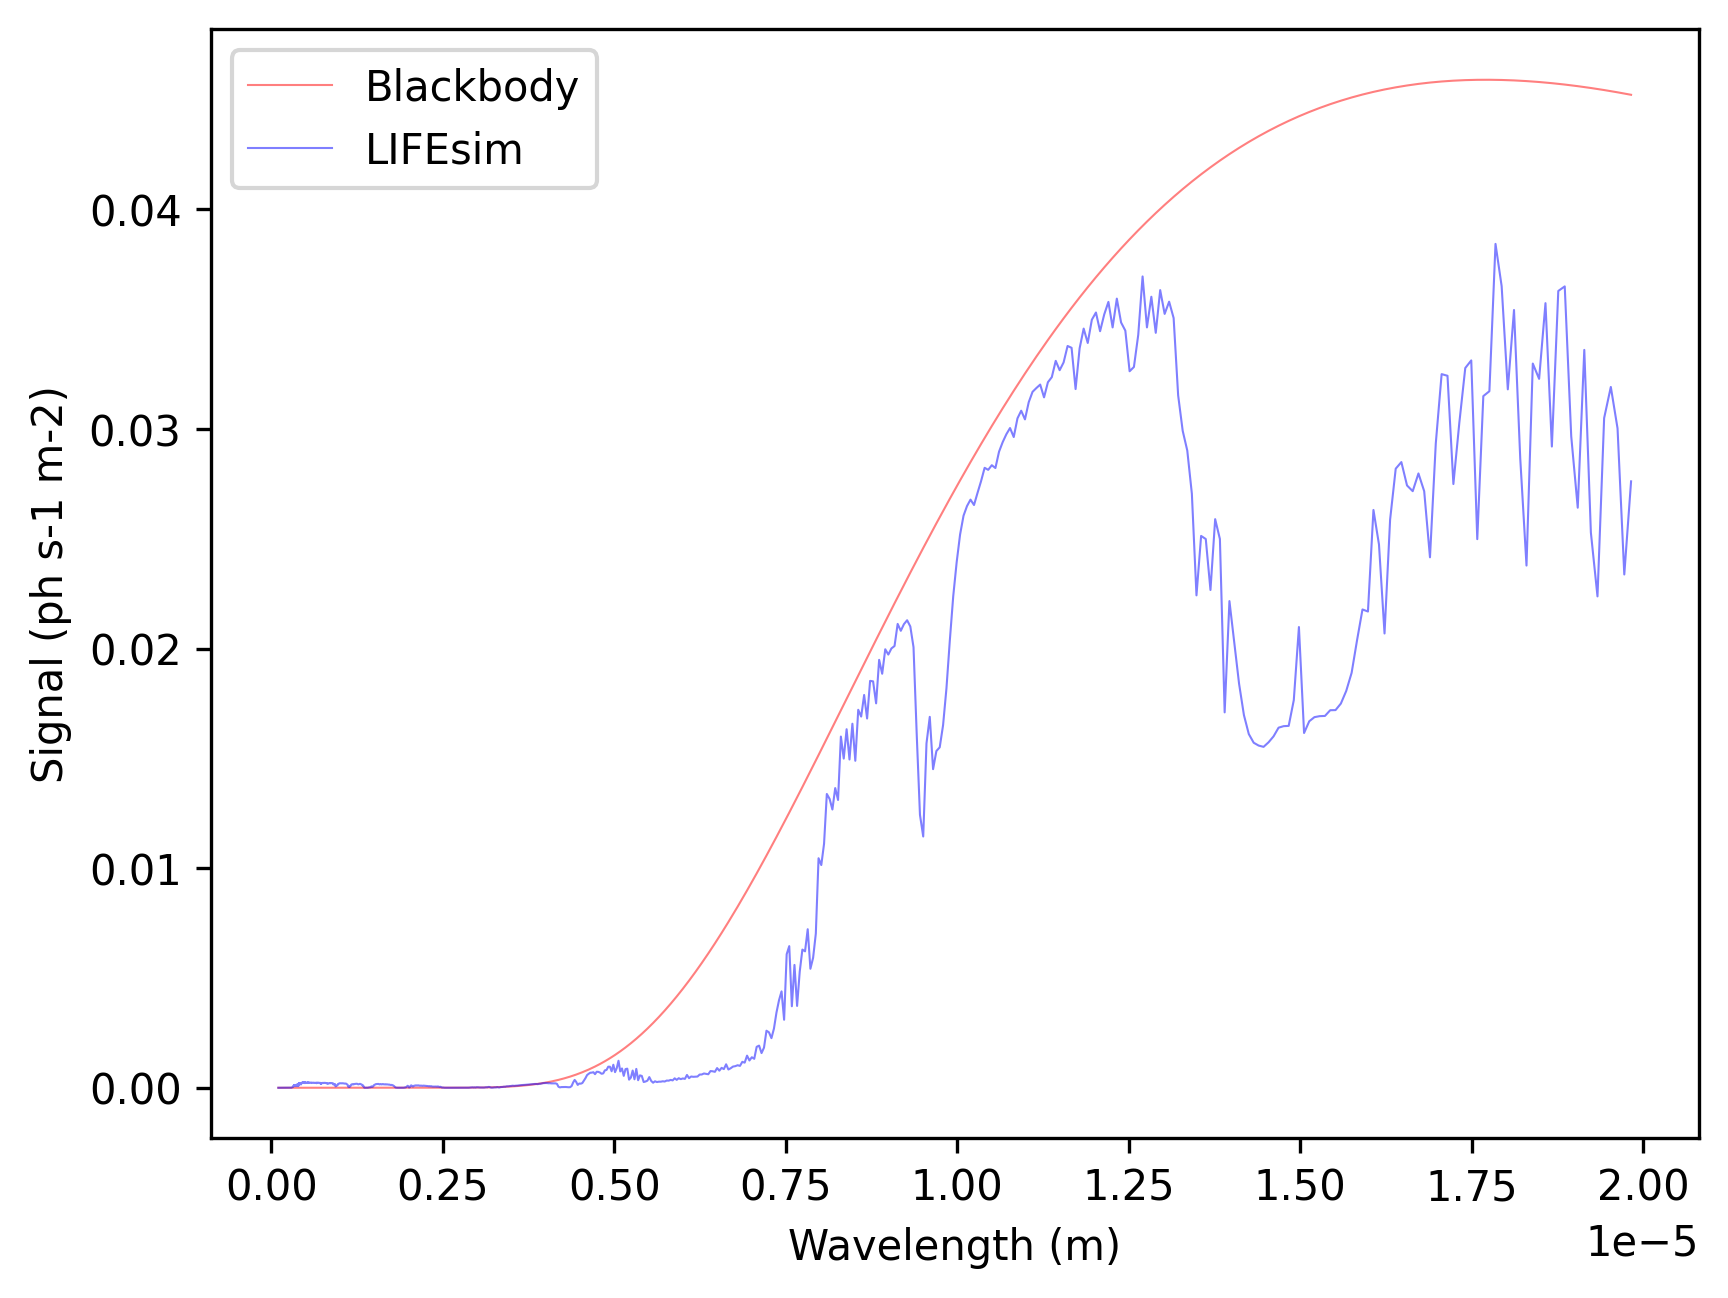

In [10]:
fig, ax = plt.subplots(dpi=300)
ln1 = plt.plot(lam_lifesim.value, bb, lw=0.5, c='red', alpha=0.5, label='Blackbody')
ln2 = plt.plot(lam_lifesim.value, f_lifesim, lw=0.5, c='blue', alpha=0.5, label='LIFEsim')

lns = ln1 + ln2
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)

#ax.set_yscale('log')
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph s-1 m-2)')
plt.show()

# LIFEsim setup

In [11]:
bus = lifesim.Bus()

bus.data.options.set_scenario('baseline')
# bus.data.options.set_manual(dc_per_pix=dc_per_pic, detector_temperature=detector_temperature, ota_temperature=ota_temperature, instrument_temperature=instrument_temperature)

In [12]:
instrument = lifesim.Instrument(name='inst')
bus.add_module(instrument)

transm = lifesim.TransmissionMap(name='transm')
bus.add_module(transm)

exo = lifesim.PhotonNoiseExozodi(name='exo')
bus.add_module(exo)
local = lifesim.PhotonNoiseLocalzodi(name='local')
bus.add_module(local)
star = lifesim.PhotonNoiseStar(name='star')
bus.add_module(star)
mirror = lifesim.PhotonNoiseThermal(name='mirror')
bus.add_module(mirror)
darkcurrent = lifesim.ElectronNoiseDarkCurrent(name='darkcurrent')
bus.add_module(darkcurrent)


# connect all modules
bus.connect(('inst', 'transm'))
bus.connect(('inst', 'exo'))
bus.connect(('inst', 'local'))
bus.connect(('inst', 'star'))
bus.connect(('inst', 'mirror'))
bus.connect(('inst', 'darkcurrent'))


bus.connect(('star', 'transm'))

instrument.apply_options()

In [13]:
integration_time = 60*60

prefactor = (integration_time 
             * bus.data.inst['eff_tot'] 
             * bus.data.inst['telescope_area'] 
             * bus.data.inst['wl_bin_widths'])

# LIFEsim no instrument setup

In [14]:
bus_noinst = lifesim.Bus()

bus_noinst.data.options.set_scenario('baseline')
bus_noinst.data.options.set_manual(dc_per_pix=dc_per_pic, detector_temperature=detector_temperature)

In [15]:
instrument_noinst = lifesim.Instrument(name='inst_noinst')
bus_noinst.add_module(instrument_noinst)

transm = lifesim.TransmissionMap(name='transm_noinst')
bus_noinst.add_module(transm)

exo_noinst = lifesim.PhotonNoiseExozodi(name='exo_noinst')
bus_noinst.add_module(exo_noinst)
local_noinst = lifesim.PhotonNoiseLocalzodi(name='local_noinst')
bus_noinst.add_module(local_noinst)
star_noinst = lifesim.PhotonNoiseStar(name='star_noinst')
bus_noinst.add_module(star_noinst)


# connect all modules
bus_noinst.connect(('inst_noinst', 'transm_noinst'))
bus_noinst.connect(('inst_noinst', 'exo_noinst'))
bus_noinst.connect(('inst_noinst', 'local_noinst'))
bus_noinst.connect(('inst_noinst', 'star_noinst'))

bus_noinst.connect(('star_noinst', 'transm_noinst'))

instrument_noinst.apply_options()

In [16]:
integration_time = 60*60

prefactor_noinst = (integration_time 
             * bus_noinst.data.inst['eff_tot'] 
             * bus_noinst.data.inst['telescope_area'] 
             * bus_noinst.data.inst['wl_bin_widths'])

# run spectrum through LIFEsim

In [17]:
spectrum, flux_planet, noise = instrument.get_spectrum(temp_s=5778,  # star temperature in K
                                                    radius_s=1,  # star radius in solar radii
                                                    distance_s=10,  # distance to system in pc
                                                    lat_s=0.78,  # ecliptic latitude of observation in rad
                                                    z=3,  # zodi level
                                                    angsep=0.1,  # angular separation of planet in arcsec
                                                    flux_planet_spectrum=[lam_lifesim, f_lifesim],
                                                    safe_mode=True,
                                                    integration_time=integration_time)

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_32869/2342845030.py:3: SyntaxWarning: invalid escape sequence '\c'
  ln2 = plt.plot(spectrum[0], flux_planet / prefactor, c='tab:cyan', label='LIFEsim spectrum $\cdot$ throughput')


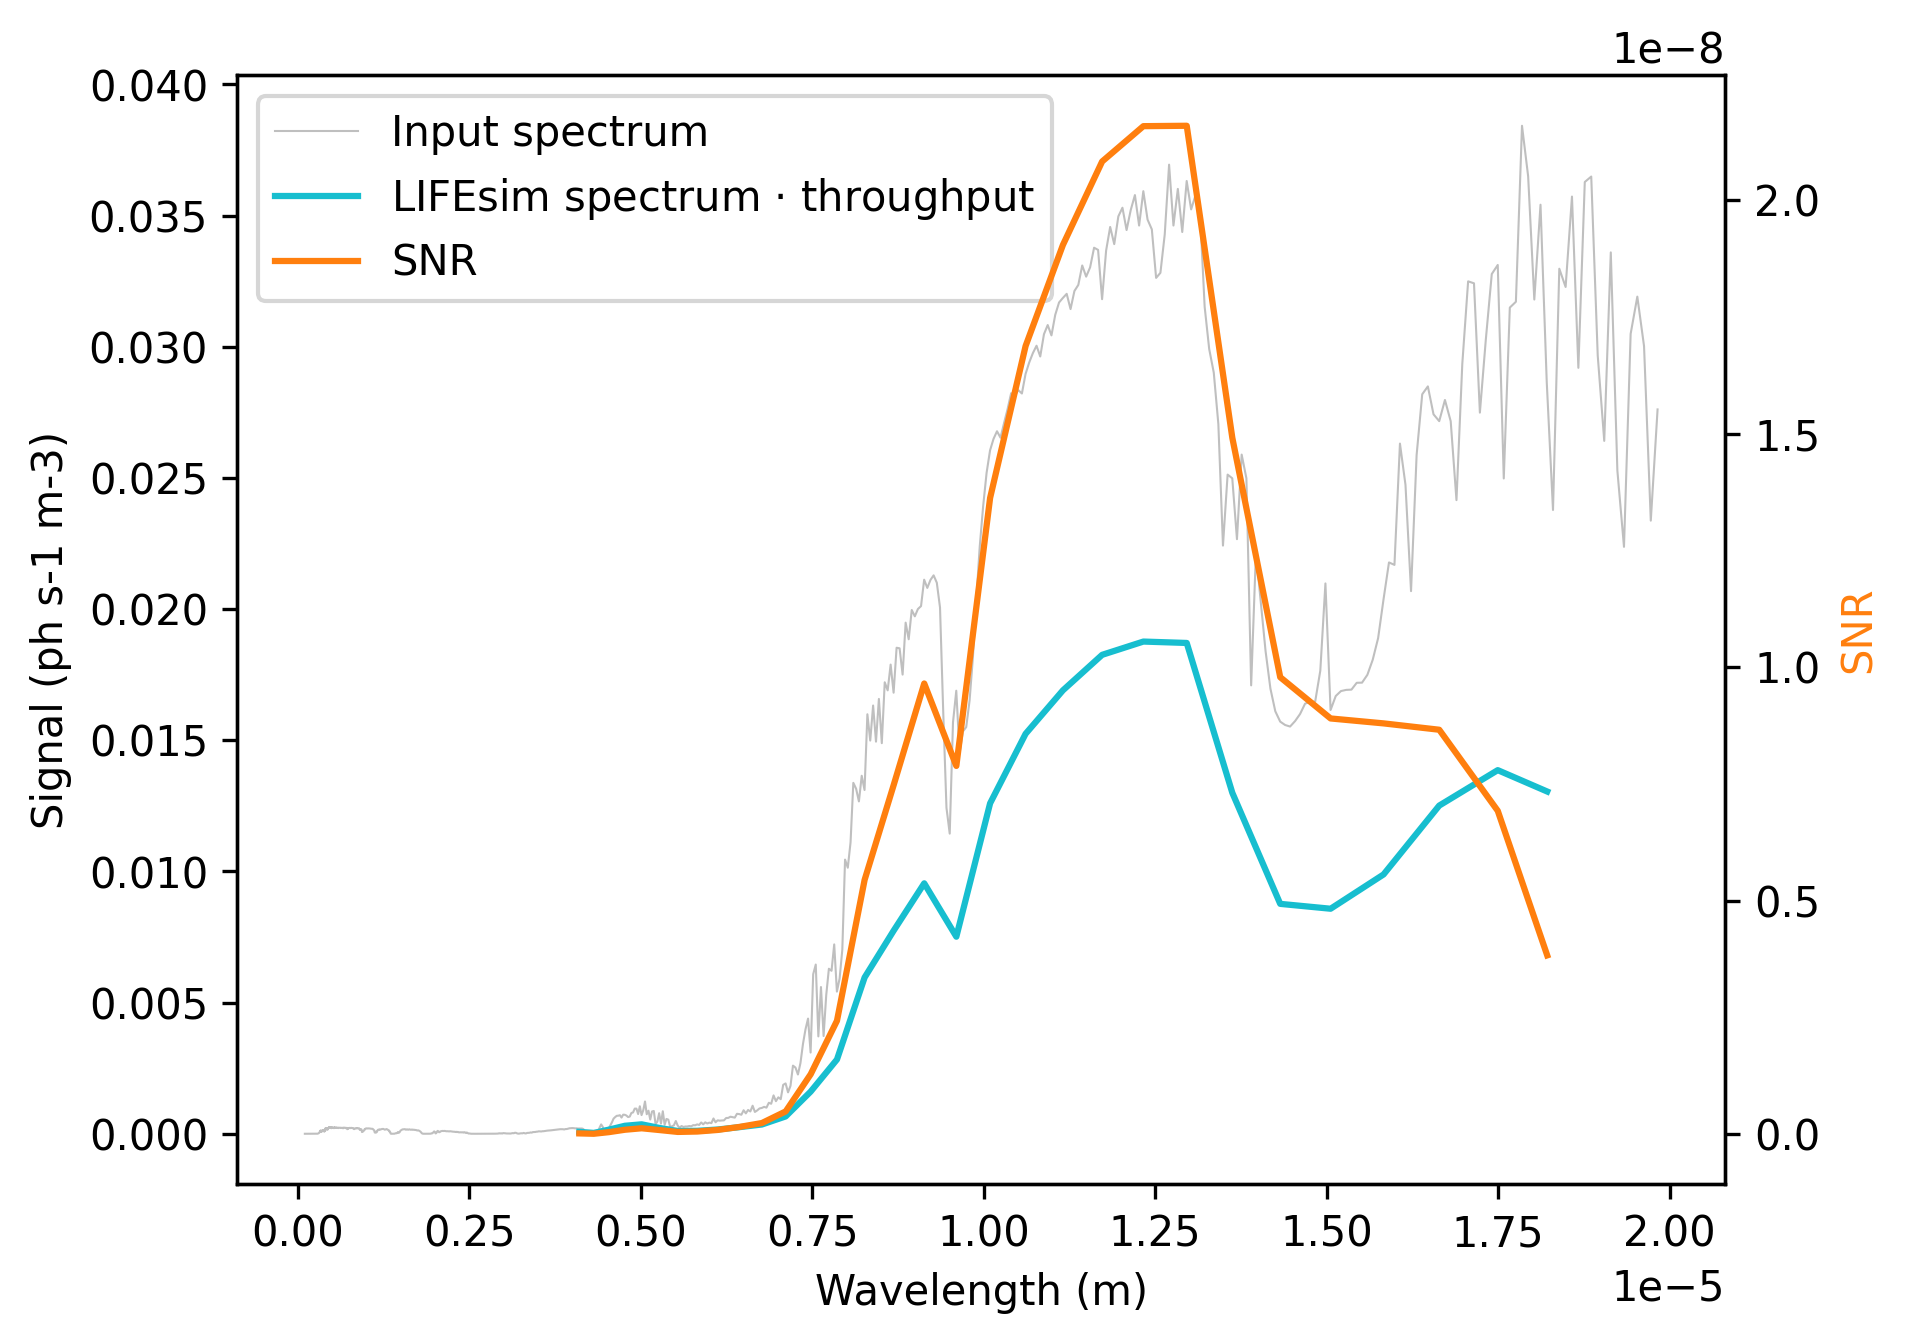

In [18]:
fig, ax = plt.subplots(dpi=300)
ln1 = plt.plot(lam_lifesim, f_lifesim, lw=0.5, c='gray', alpha=0.5, label='Input spectrum')
ln2 = plt.plot(spectrum[0], flux_planet / prefactor, c='tab:cyan', label='LIFEsim spectrum $\cdot$ throughput')
ax2=ax.twinx()
ln3 = ax2.plot(spectrum[0], spectrum[1],c='tab:orange', label='SNR')

lns = ln1 + ln2 + ln3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)

ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph s-1 m-3)')
ax2.set_ylabel("SNR",c='tab:orange')
plt.show()

# safe mode off

In [19]:
# test safe mode off
spectrum_tmo, flux_planet_tmo, noise_tmo = instrument.get_spectrum(temp_s=5778,  # star temperature in K
                                                    radius_s=1,  # star radius in solar radii
                                                    distance_s=10,  # distance to system in pc
                                                    lat_s=0.78,  # ecliptic latitude of observation in rad
                                                    z=3,  # zodi level
                                                    angsep=0.1,  # angular separation of planet in arcsec
                                                    flux_planet_spectrum=[lam_lifesim, f_lifesim],
                                                    safe_mode=True,
                                                    integration_time=integration_time)

In [20]:
noise_star = noise_tmo[1]
noise_star_local = noise_star[0]
noise_star_starleak = noise_star[1]

noise_universe = noise_tmo[2][0]

noise_thermal = noise_tmo[3] 
noise_thermal_mirror = noise_thermal[0]
noise_thermal_detector = noise_thermal[2]
noise_thermal_inst = noise_thermal[1]

noise_dc_electron = noise_tmo[4][0]
noise_dc_photon = noise_dc_electron/0.7

noise_planet = noise_tmo[0]/integration_time/bus.data.inst['eff_tot']/bus.data.options.array['num_outputs'] - noise_star_local - noise_star_starleak - noise_universe - noise_thermal_mirror - noise_thermal_detector - noise_dc_photon

In [21]:
noise_dc_photon

array([15.61290323, 15.61290323, 15.61290323, 15.61290323, 15.61290323,
       15.61290323, 15.61290323, 15.61290323, 15.61290323, 15.61290323,
       15.61290323, 15.61290323, 15.61290323, 15.61290323, 15.61290323,
       15.61290323, 15.61290323, 15.61290323, 15.61290323, 15.61290323,
       15.61290323, 15.61290323, 15.61290323, 15.61290323, 15.61290323,
       15.61290323, 15.61290323, 15.61290323, 15.61290323, 15.61290323,
       15.61290323])

In [22]:
noise_dc_electron

array([10.92903226, 10.92903226, 10.92903226, 10.92903226, 10.92903226,
       10.92903226, 10.92903226, 10.92903226, 10.92903226, 10.92903226,
       10.92903226, 10.92903226, 10.92903226, 10.92903226, 10.92903226,
       10.92903226, 10.92903226, 10.92903226, 10.92903226, 10.92903226,
       10.92903226, 10.92903226, 10.92903226, 10.92903226, 10.92903226,
       10.92903226, 10.92903226, 10.92903226, 10.92903226, 10.92903226,
       10.92903226])

In [23]:
x = spectrum_tmo[0] * 1e6

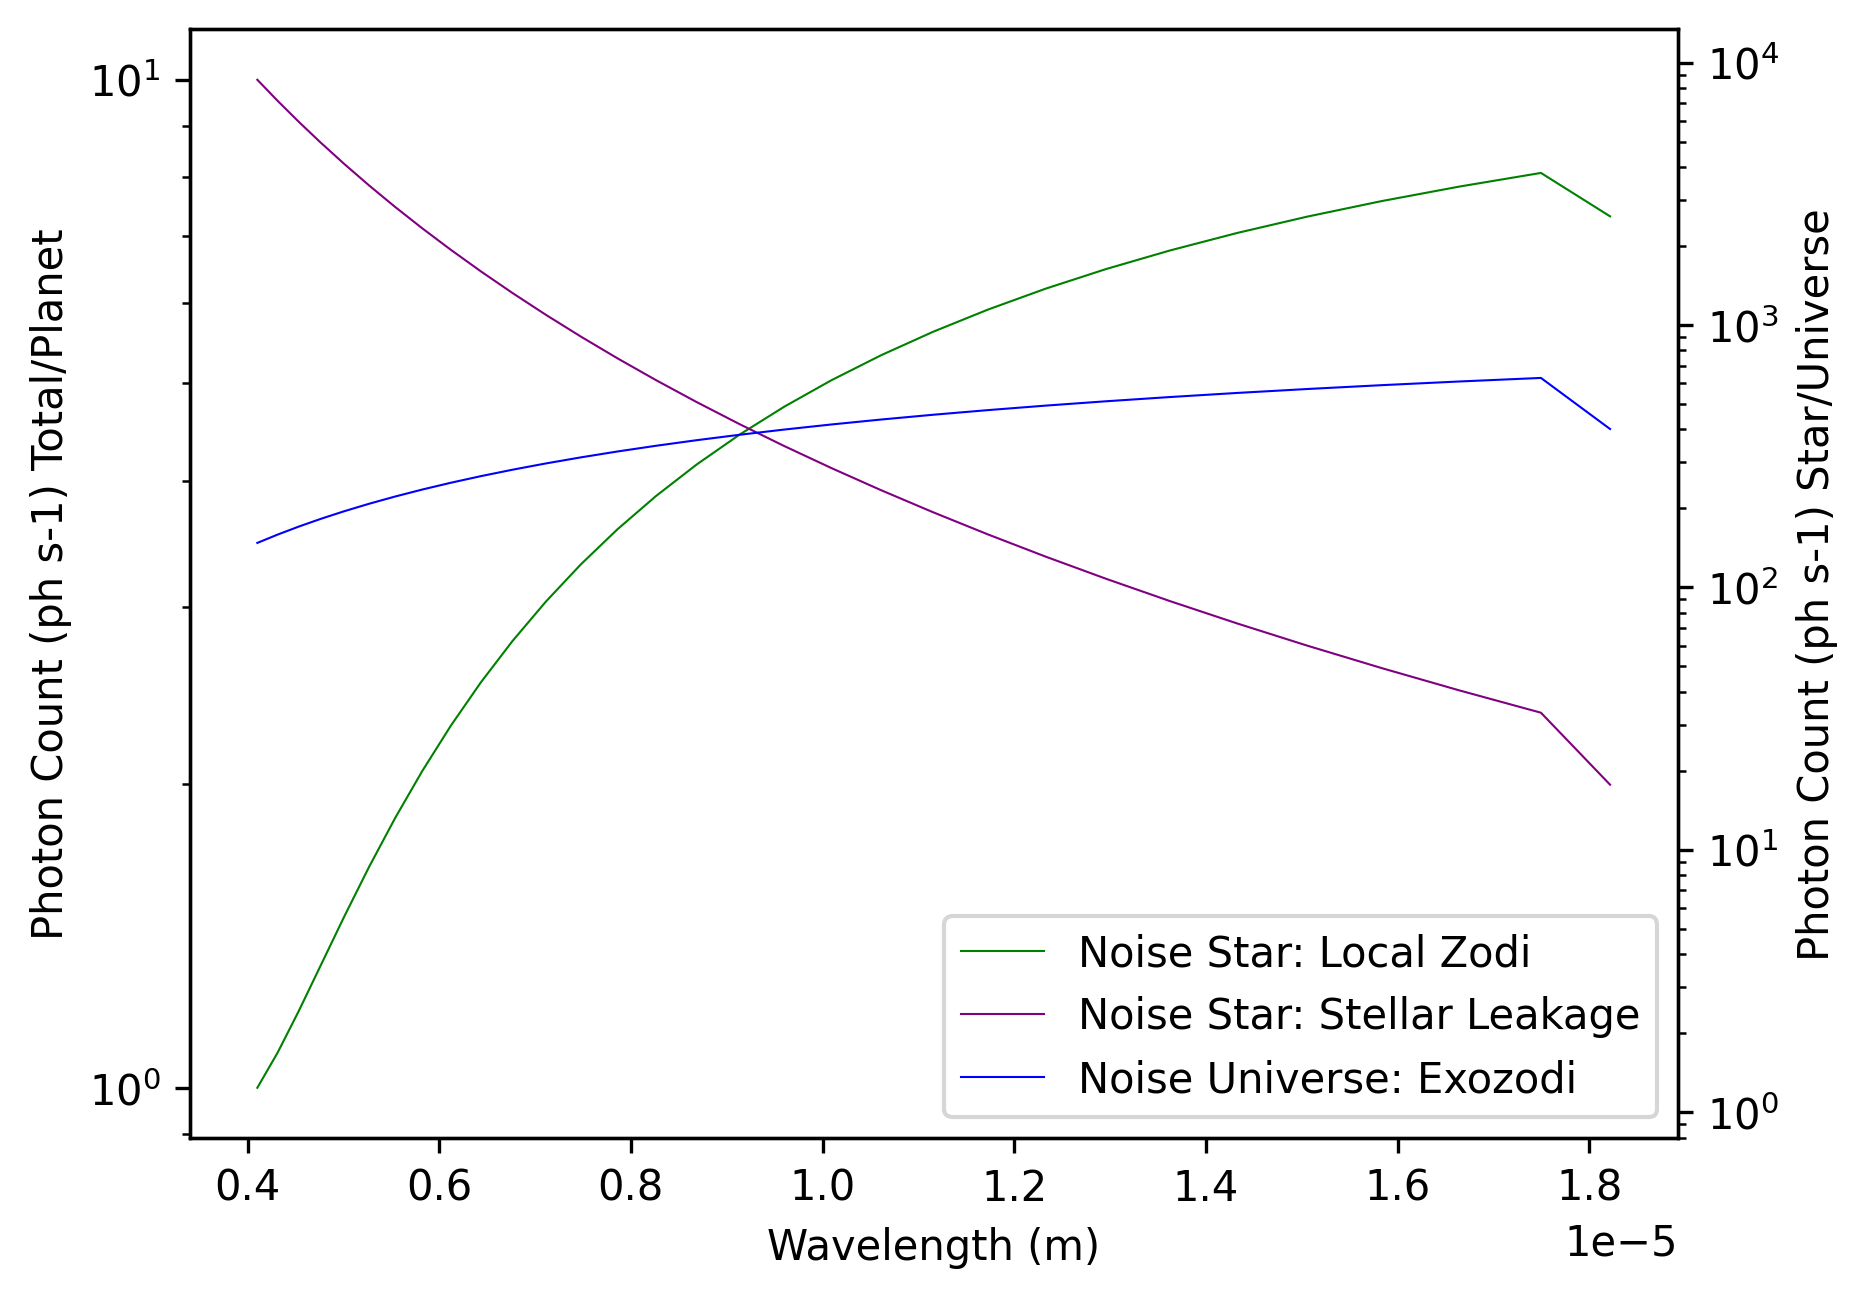

In [24]:
fig, ax = plt.subplots(dpi=300)

# lntot = plt.plot(spectrum_tmo[0], noise_tmo[0], lw=0.5, c='black', label='Total Noise')
# lnplanet = plt.plot(spectrum_tmo[0], noise_planet, lw=0.5, c='gray', label='Noise Planet')

ax2=ax.twinx()
ln1 = ax2.plot(spectrum_tmo[0], noise_star_local, lw=0.5, c='green', label='Noise Star: Local Zodi')
ln2 = ax2.plot(spectrum_tmo[0], noise_star_starleak, lw=0.5, c='purple', label='Noise Star: Stellar Leakage')
ln3 = ax2.plot(spectrum_tmo[0], noise_universe, lw=0.5, c='blue', label='Noise Universe: Exozodi')

lns = ln1 + ln2 + ln3 # + lntot + lnplanet
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel("Photon Count (ph s-1) Total/Planet")
ax2.set_yscale('log')
ax2.set_ylabel('Photon Count (ph s-1) Star/Universe')

plt.show()

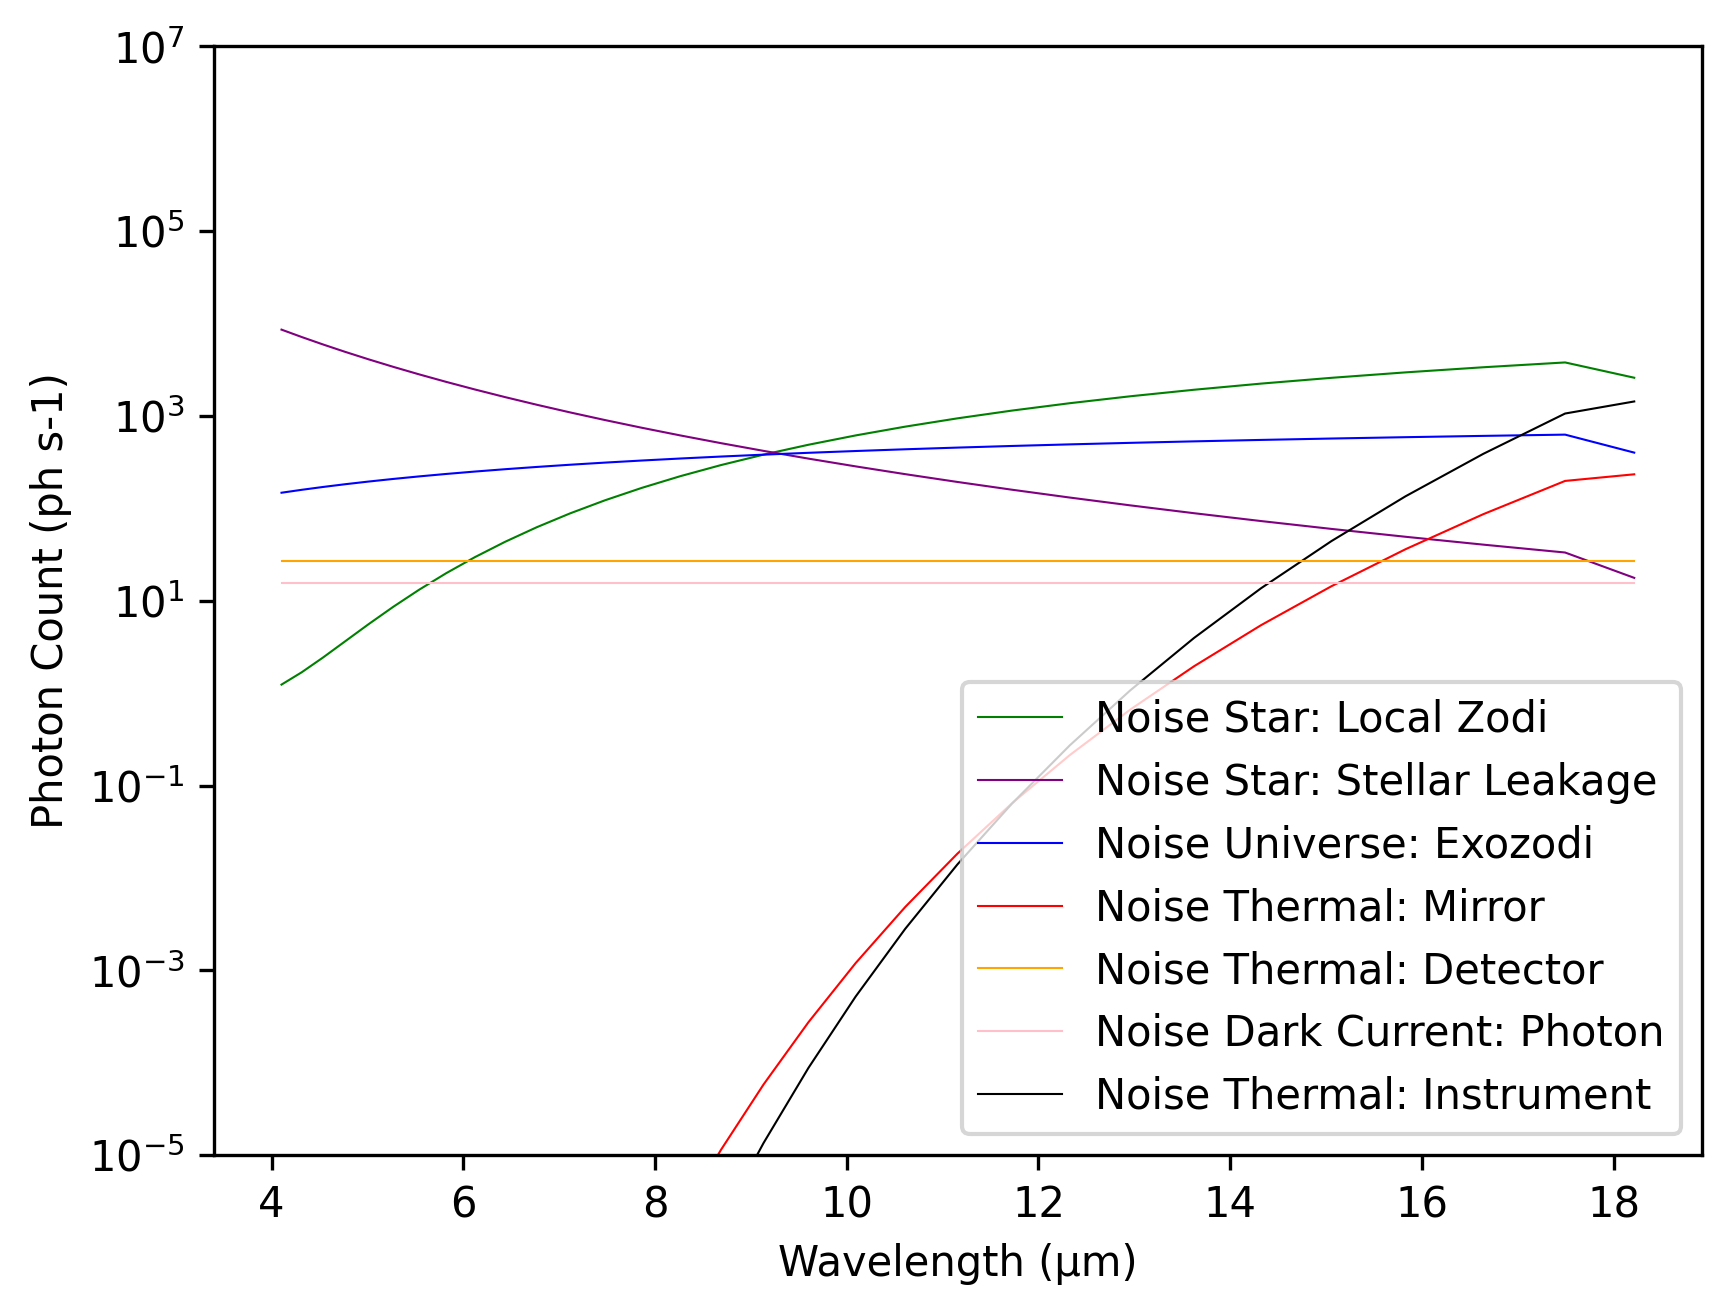

In [25]:
fig, ax = plt.subplots(dpi=300)

# lntot = plt.plot(spectrum_tmo[0], noise_tmo[0], lw=0.5, c='black', label='Total Noise')
# lnplanet = plt.plot(spectrum_tmo[0], noise_planet, lw=0.5, c='gray', label='Noise Planet')

ln1 = plt.plot(x, noise_star_local, lw=0.5, c='green', label='Noise Star: Local Zodi')
ln2 = plt.plot(x, noise_star_starleak, lw=0.5, c='purple', label='Noise Star: Stellar Leakage')
ln3 = plt.plot(x, noise_universe, lw=0.5, c='blue', label='Noise Universe: Exozodi')

ln4 = plt.plot(x, noise_thermal_mirror, lw=0.5, c='red', label='Noise Thermal: Mirror')
ln7 = plt.plot(x, noise_thermal_inst, lw=0.5, c='black', label='Noise Thermal: Instrument')
ln5 = plt.plot(x, noise_thermal_detector, lw=0.5, c='orange', label='Noise Thermal: Detector')
ln6 = plt.plot(x, noise_dc_photon, lw=0.5, c='pink', label='Noise Dark Current: Photon')

lns = ln1 + ln2 + ln3 + ln4 + ln5 + ln6 + ln7 # + lntot + lnplanet
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel("Photon Count (ph s-1)")
ax.set_ylim(1e-5, 1e7)

plt.show()

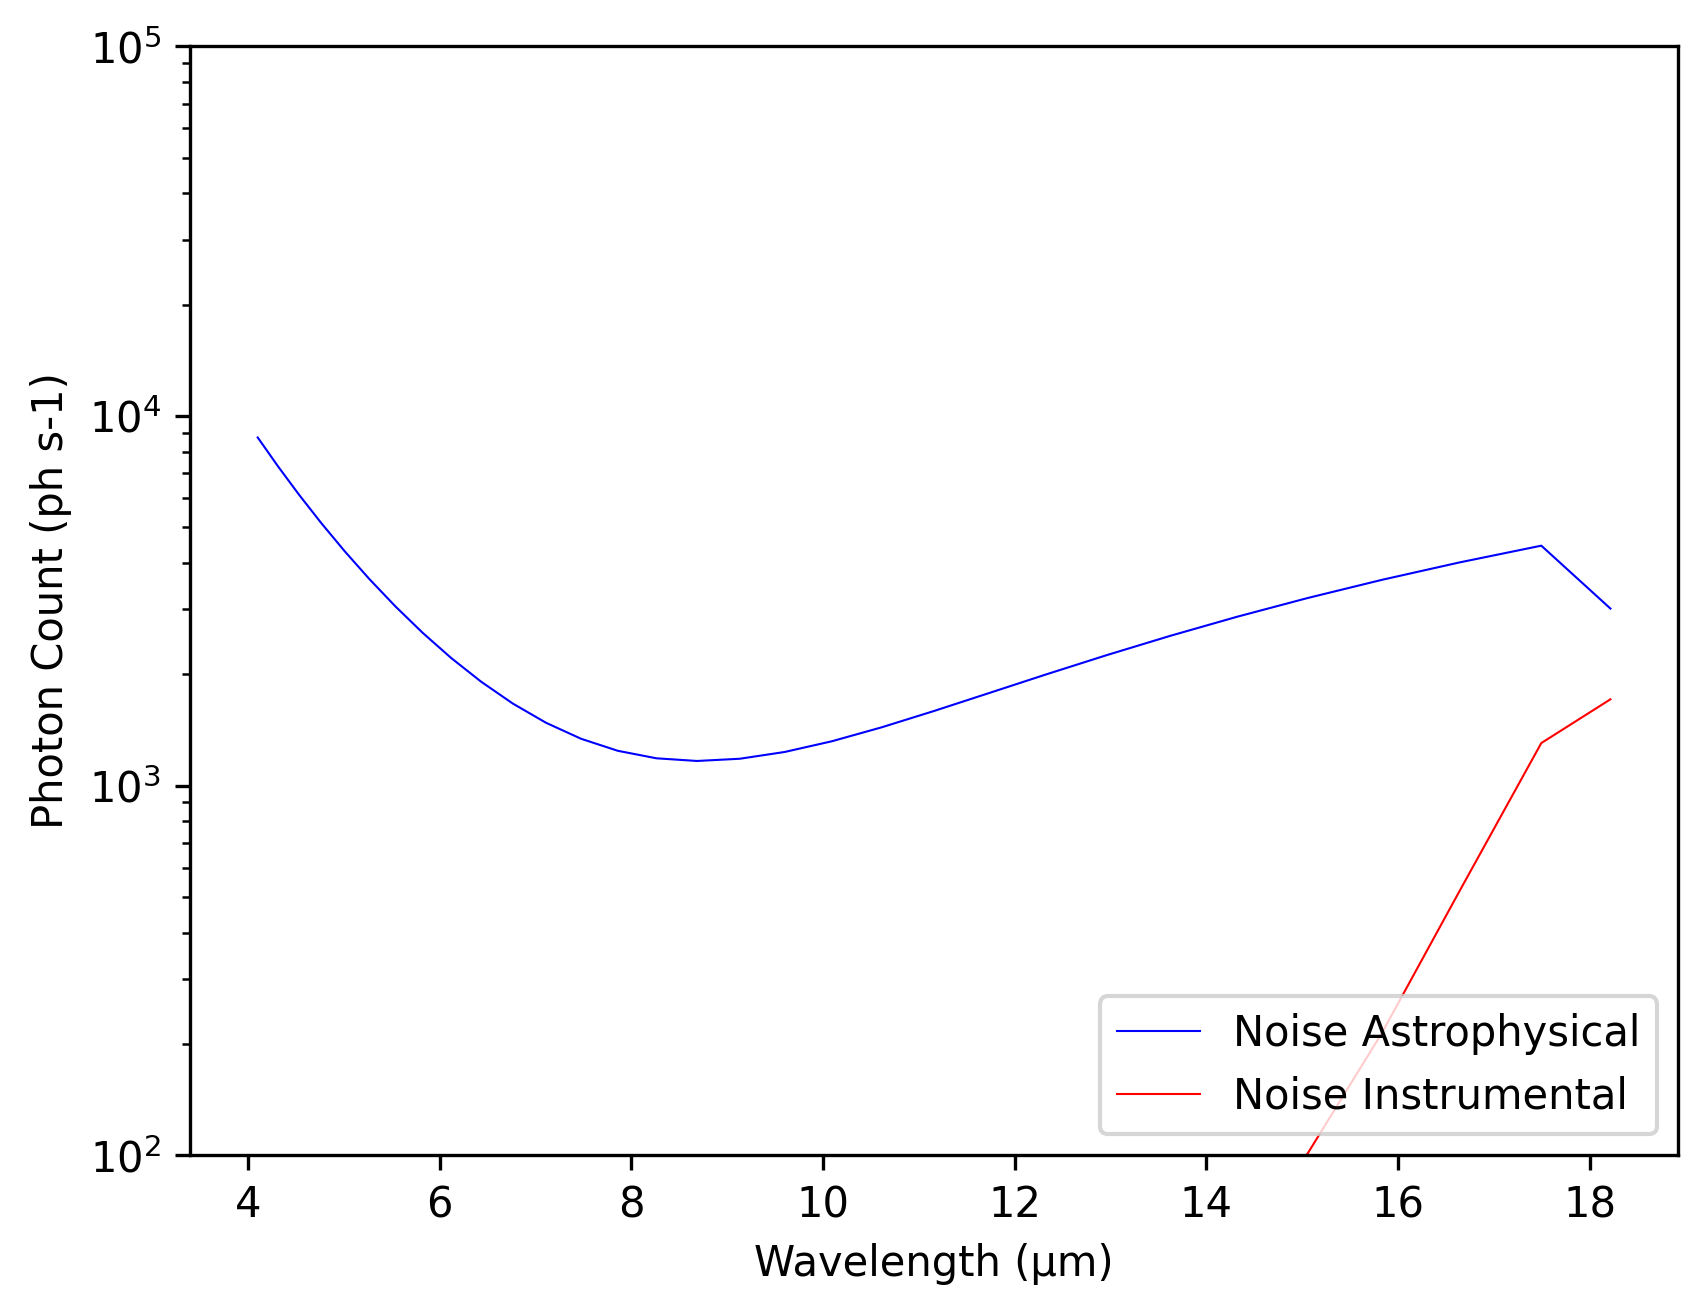

In [26]:
fig, ax = plt.subplots(dpi=300)

# lntot = plt.plot(x, noise_tmo[0], lw=0.5, c='black', label='Total Noise')
# lnplanet = plt.plot(x, noise_planet, lw=0.5, c='gray', label='Noise Planet')

noise_astrophysical = noise_star_local + noise_star_starleak + noise_universe
noise_instrumental = noise_thermal_mirror + noise_thermal_detector + noise_dc_photon + noise_thermal_inst

ln1 = plt.plot(x, noise_astrophysical, lw=0.5, c='blue', label='Noise Astrophysical')
ln2 = plt.plot(x, noise_instrumental, lw=0.5, c='red', label='Noise Instrumental')

lns = ln1 + ln2 # + lntot + lnplanet
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel("Photon Count (ph s-1)")
ax.set_ylim(1e2, 1e5)

plt.show()

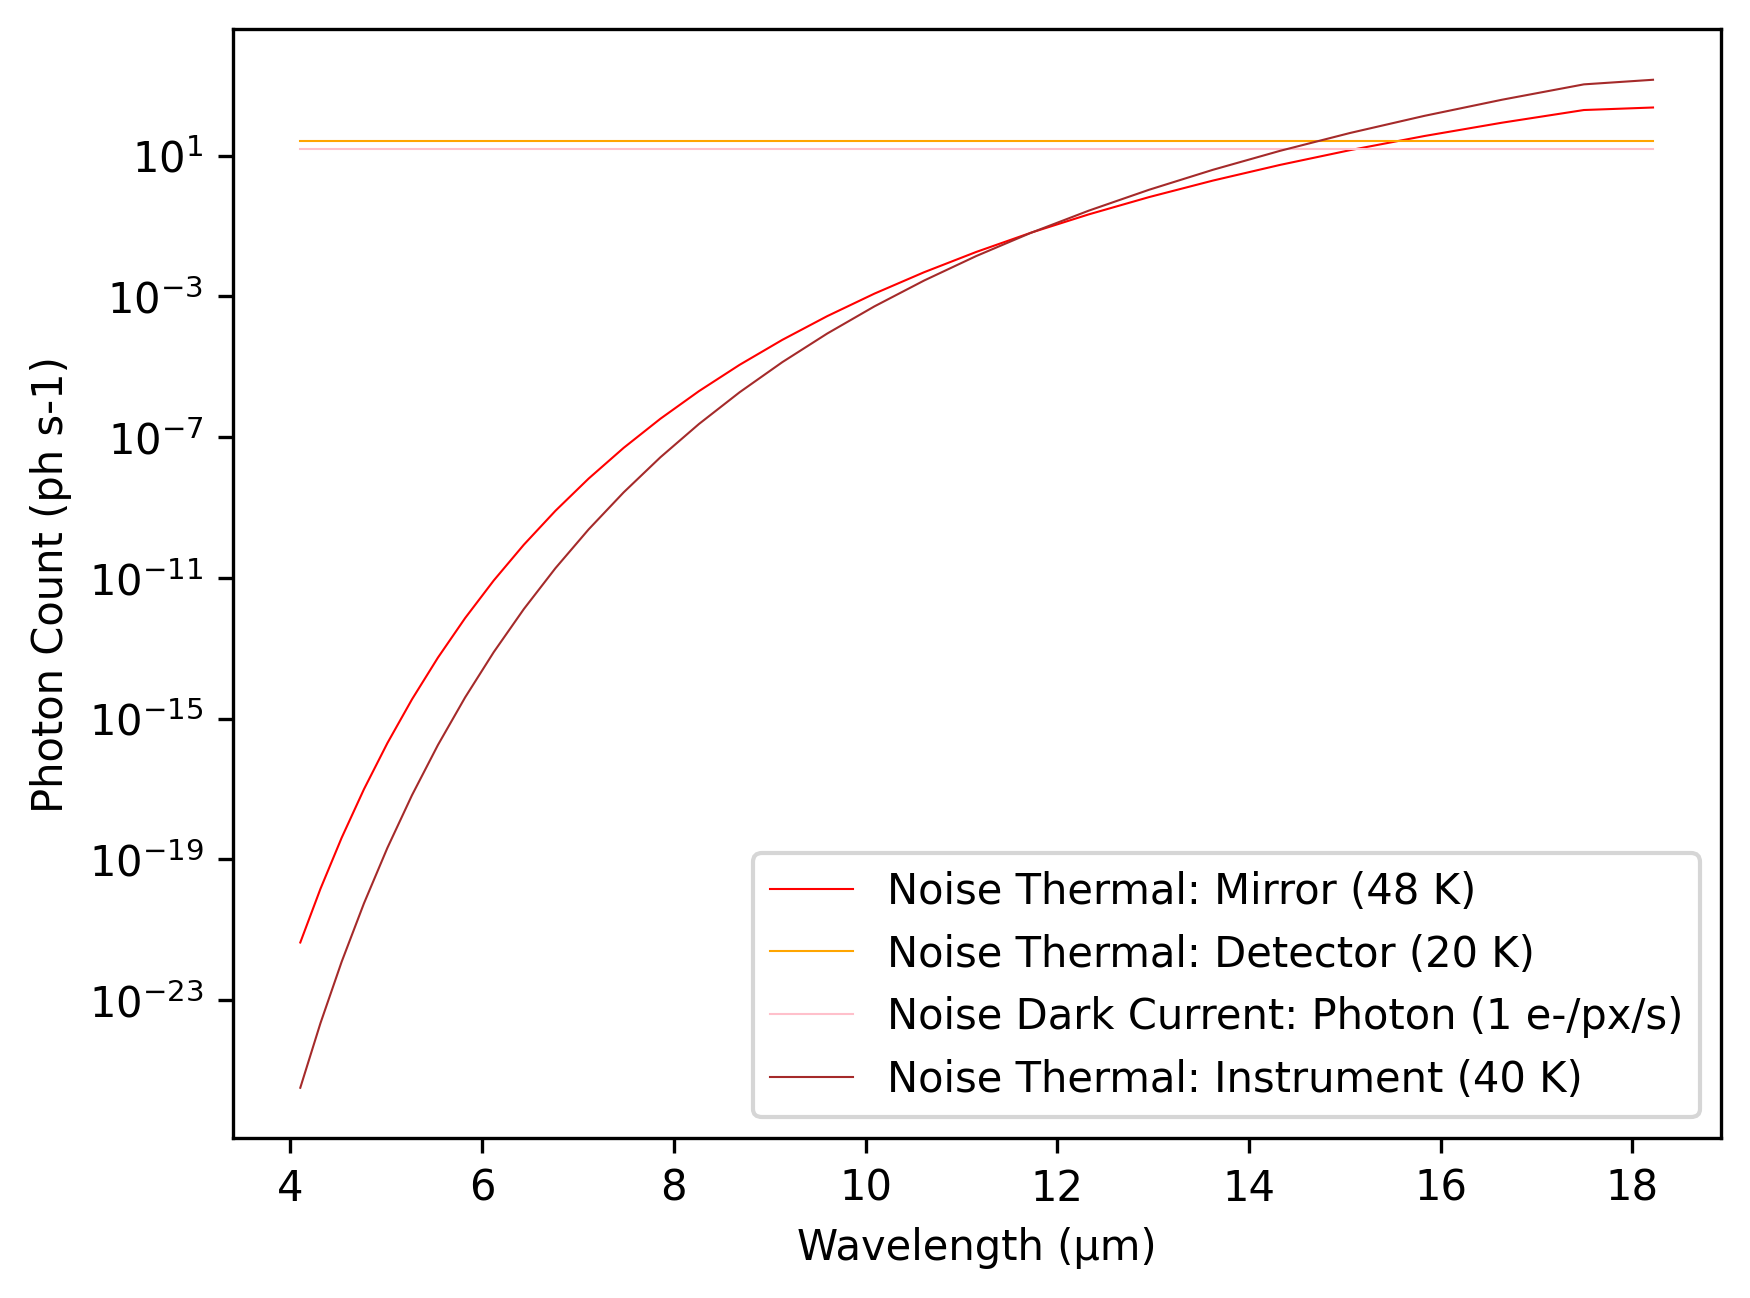

In [27]:
fig, ax = plt.subplots(dpi=300)

# lntot = plt.plot(spectrum_tmo[0], noise_tmo[0], lw=0.5, c='black', label='Total Noise')
# lnplanet = plt.plot(spectrum_tmo[0], noise_planet, lw=0.5, c='gray', label='Noise Planet')


ln4 = ax.plot(x, noise_thermal_mirror, lw=0.5, c='red', label=f'Noise Thermal: Mirror ({bus.data.options.thermal["ota_temperature"]} K)')
ln5 = ax.plot(x, noise_thermal_detector, lw=0.5, c='orange', label=f'Noise Thermal: Detector ({bus.data.options.thermal["detector_temperature"]} K)')
ln6 = ax.plot(x, noise_dc_photon, lw=0.5, c='pink', label=f'Noise Dark Current: Photon ({bus.data.options.array["dc_per_pix"]} e-/px/s)')
ln7 = ax.plot(x, noise_thermal_inst, lw=0.5, c='brown', label=f'Noise Thermal: Instrument ({bus.data.options.thermal["instrument_temperature"]} K)')

lns = ln4 + ln5 + ln6 + ln7 # + lntot + lnplanet
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax2.set_yscale('log')
ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel("Photon Count (ph s-1)")
# ax.set_ylim(1e-5, 1e5)

plt.show()

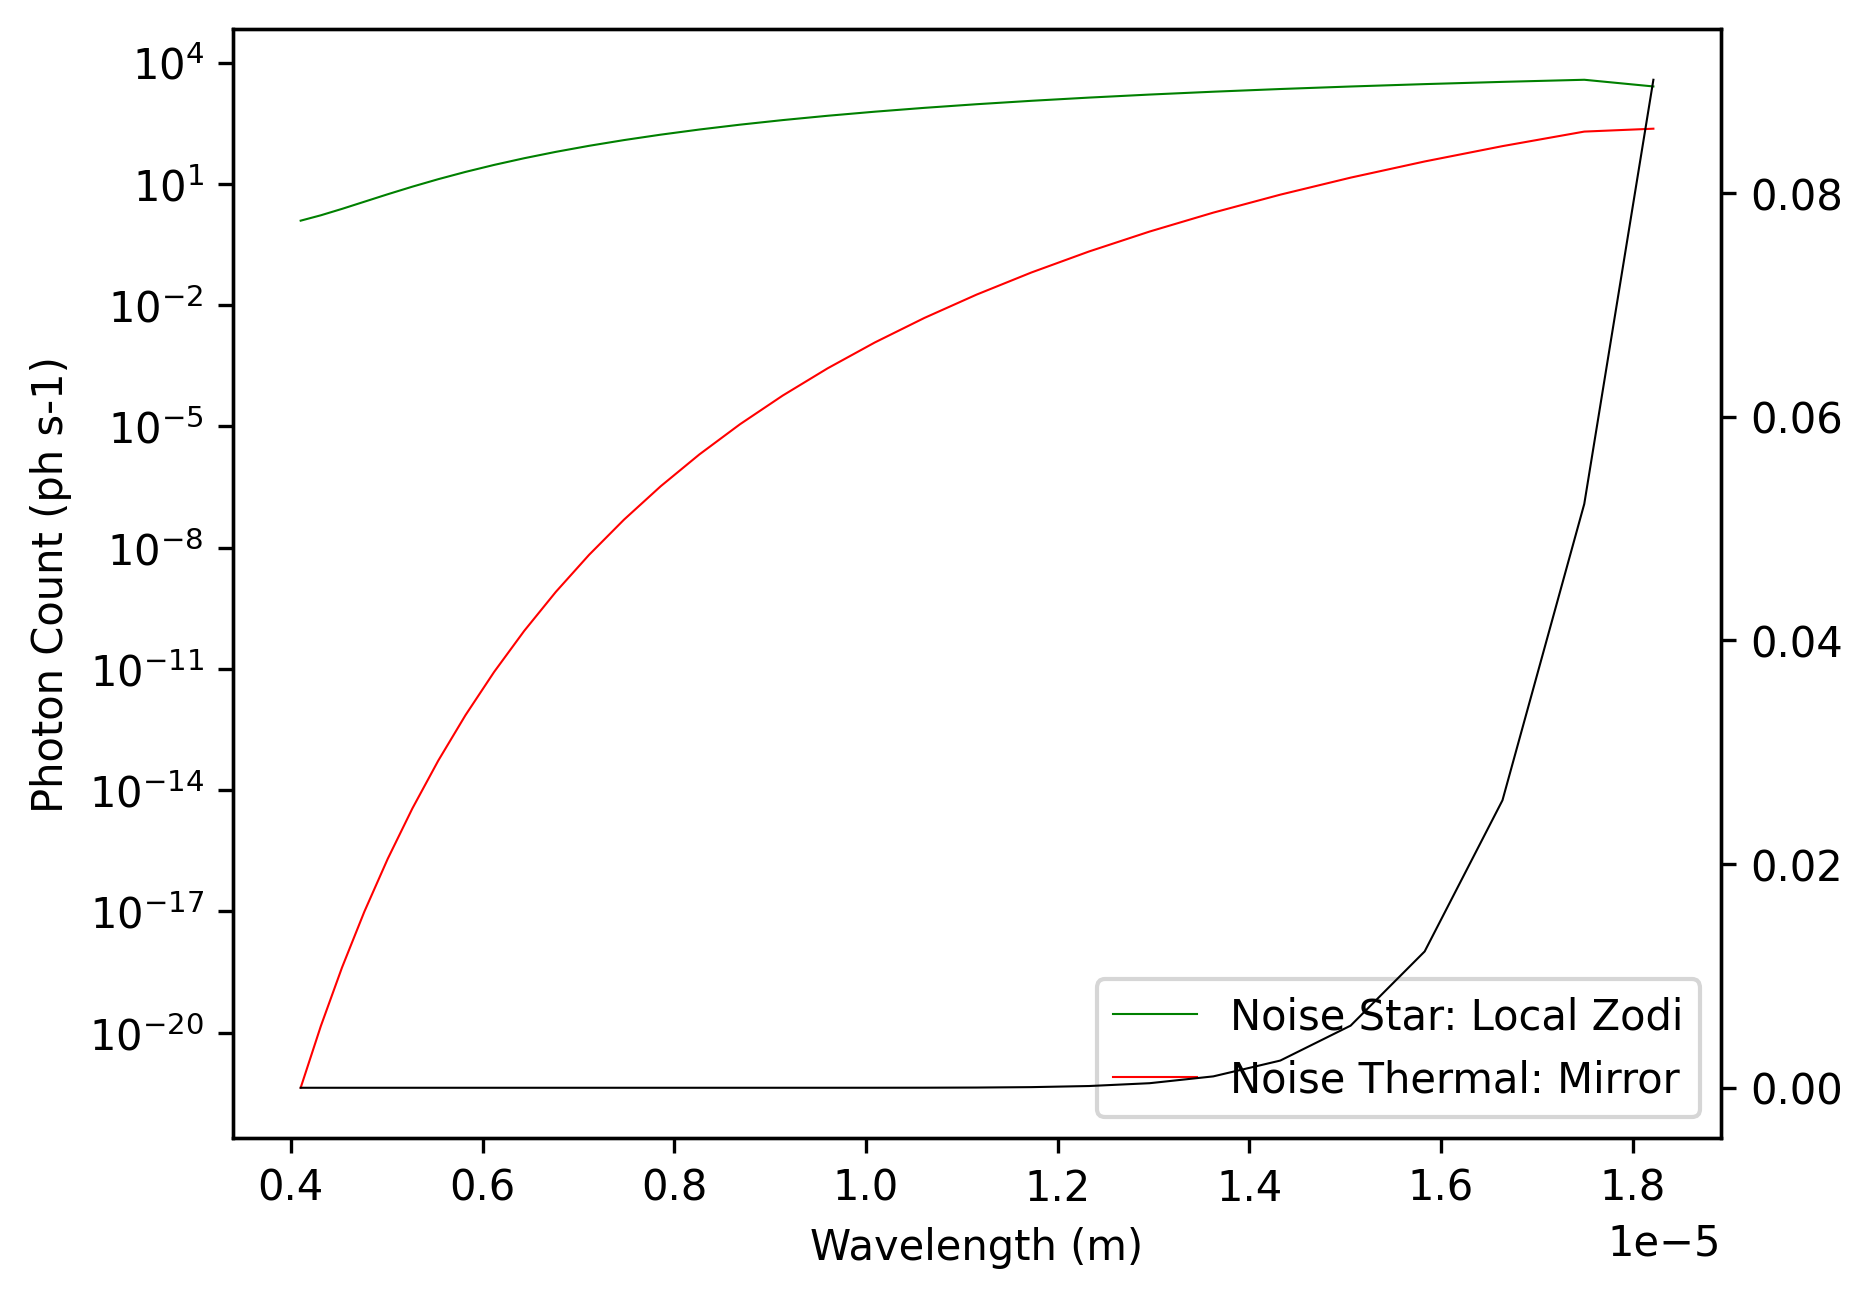

In [28]:
fig, ax = plt.subplots(dpi=300)

ln1 = plt.plot(spectrum_tmo[0], noise_star_local, lw=0.5, c='green', label='Noise Star: Local Zodi')

ln4 = plt.plot(spectrum_tmo[0], noise_thermal_mirror, lw=0.5, c='red', label='Noise Thermal: Mirror')

ax2=ax.twinx()
lncomp = ax2.plot(spectrum_tmo[0], noise_thermal_mirror/noise_star_local, lw=0.5, c='black', label='Noise Star + Thermal Mirror')

lns = ln1 + ln4
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel("Photon Count (ph s-1)")

plt.show()

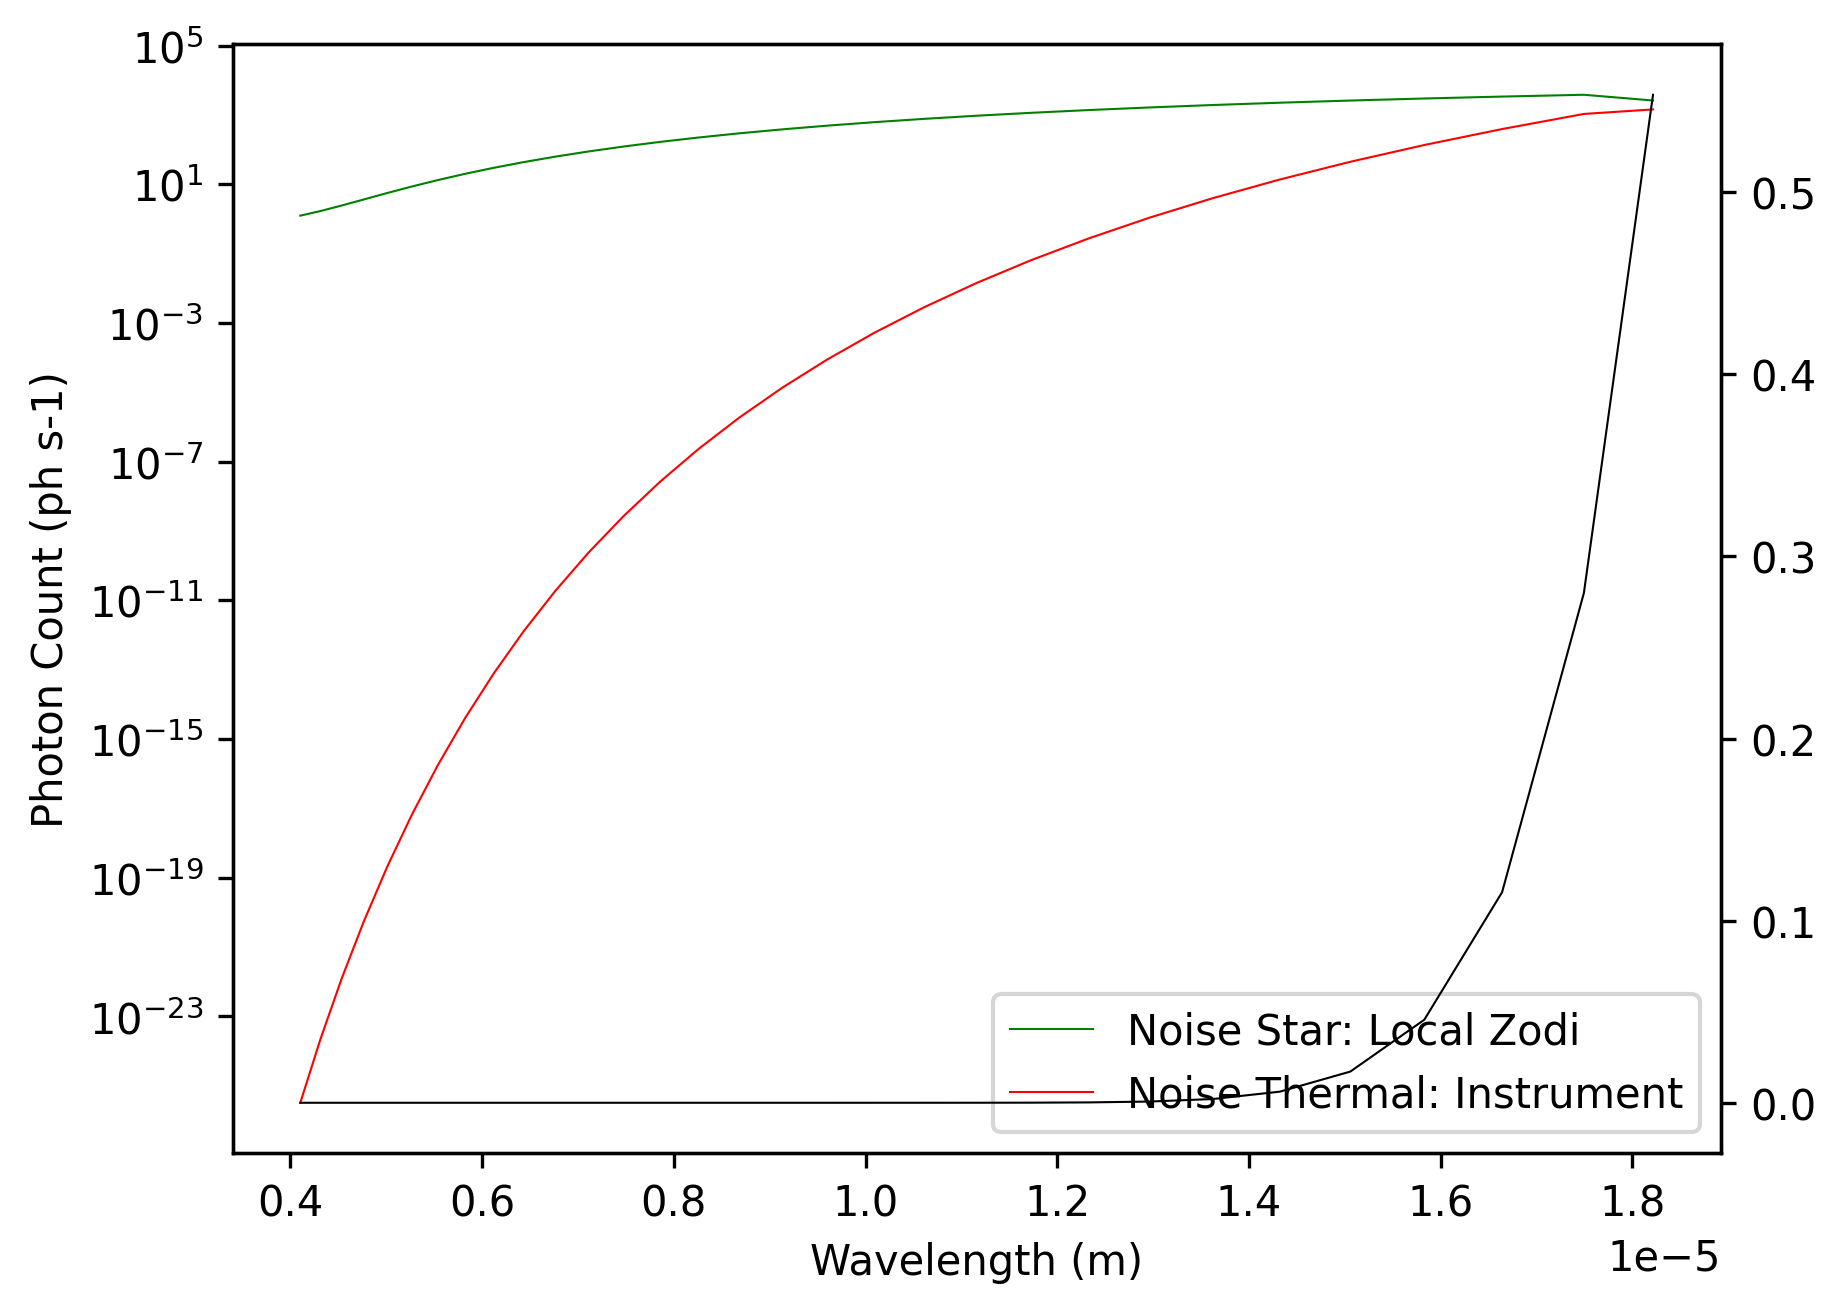

In [29]:
fig, ax = plt.subplots(dpi=300)

ln1 = plt.plot(spectrum_tmo[0], noise_star_local, lw=0.5, c='green', label='Noise Star: Local Zodi')

ln4 = plt.plot(spectrum_tmo[0], noise_thermal_inst, lw=0.5, c='red', label='Noise Thermal: Instrument')

ax2=ax.twinx()
lncomp = ax2.plot(spectrum_tmo[0], noise_thermal_inst/noise_star_local, lw=0.5, c='black', label='Noise Star + Thermal Instrument')

lns = ln1 + ln4
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel("Photon Count (ph s-1)")

plt.show()

# SNR

In [30]:
# test safe mode off
spectrum_tmo, flux_planet_tmo, noise_tmo = instrument.get_spectrum(temp_s=5778,  # star temperature in K
                                                    radius_s=1,  # star radius in solar radii
                                                    distance_s=10,  # distance to system in pc
                                                    lat_s=0.78,  # ecliptic latitude of observation in rad
                                                    z=3,  # zodi level
                                                    angsep=0.1,  # angular separation of planet in arcsec
                                                    flux_planet_spectrum=[lam_lifesim, f_lifesim],
                                                    safe_mode=True,
                                                    integration_time=integration_time)

In [31]:
# test safe mode off
spectrum_noinst, flux_planet_noinst, noise_noinst = instrument_noinst.get_spectrum(temp_s=5778,  # star temperature in K
                                                    radius_s=1,  # star radius in solar radii
                                                    distance_s=10,  # distance to system in pc
                                                    lat_s=0.78,  # ecliptic latitude of observation in rad
                                                    z=3,  # zodi level
                                                    angsep=0.1,  # angular separation of planet in arcsec
                                                    flux_planet_spectrum=[lam_lifesim, f_lifesim],
                                                    safe_mode=True,
                                                    integration_time=integration_time)

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_32869/479179688.py:3: SyntaxWarning: invalid escape sequence '\c'
  ln2 = plt.plot(spectrum_tmo[0], flux_planet_tmo / prefactor, c='tab:cyan', label='LIFEsim spectrum $\cdot$ throughput')


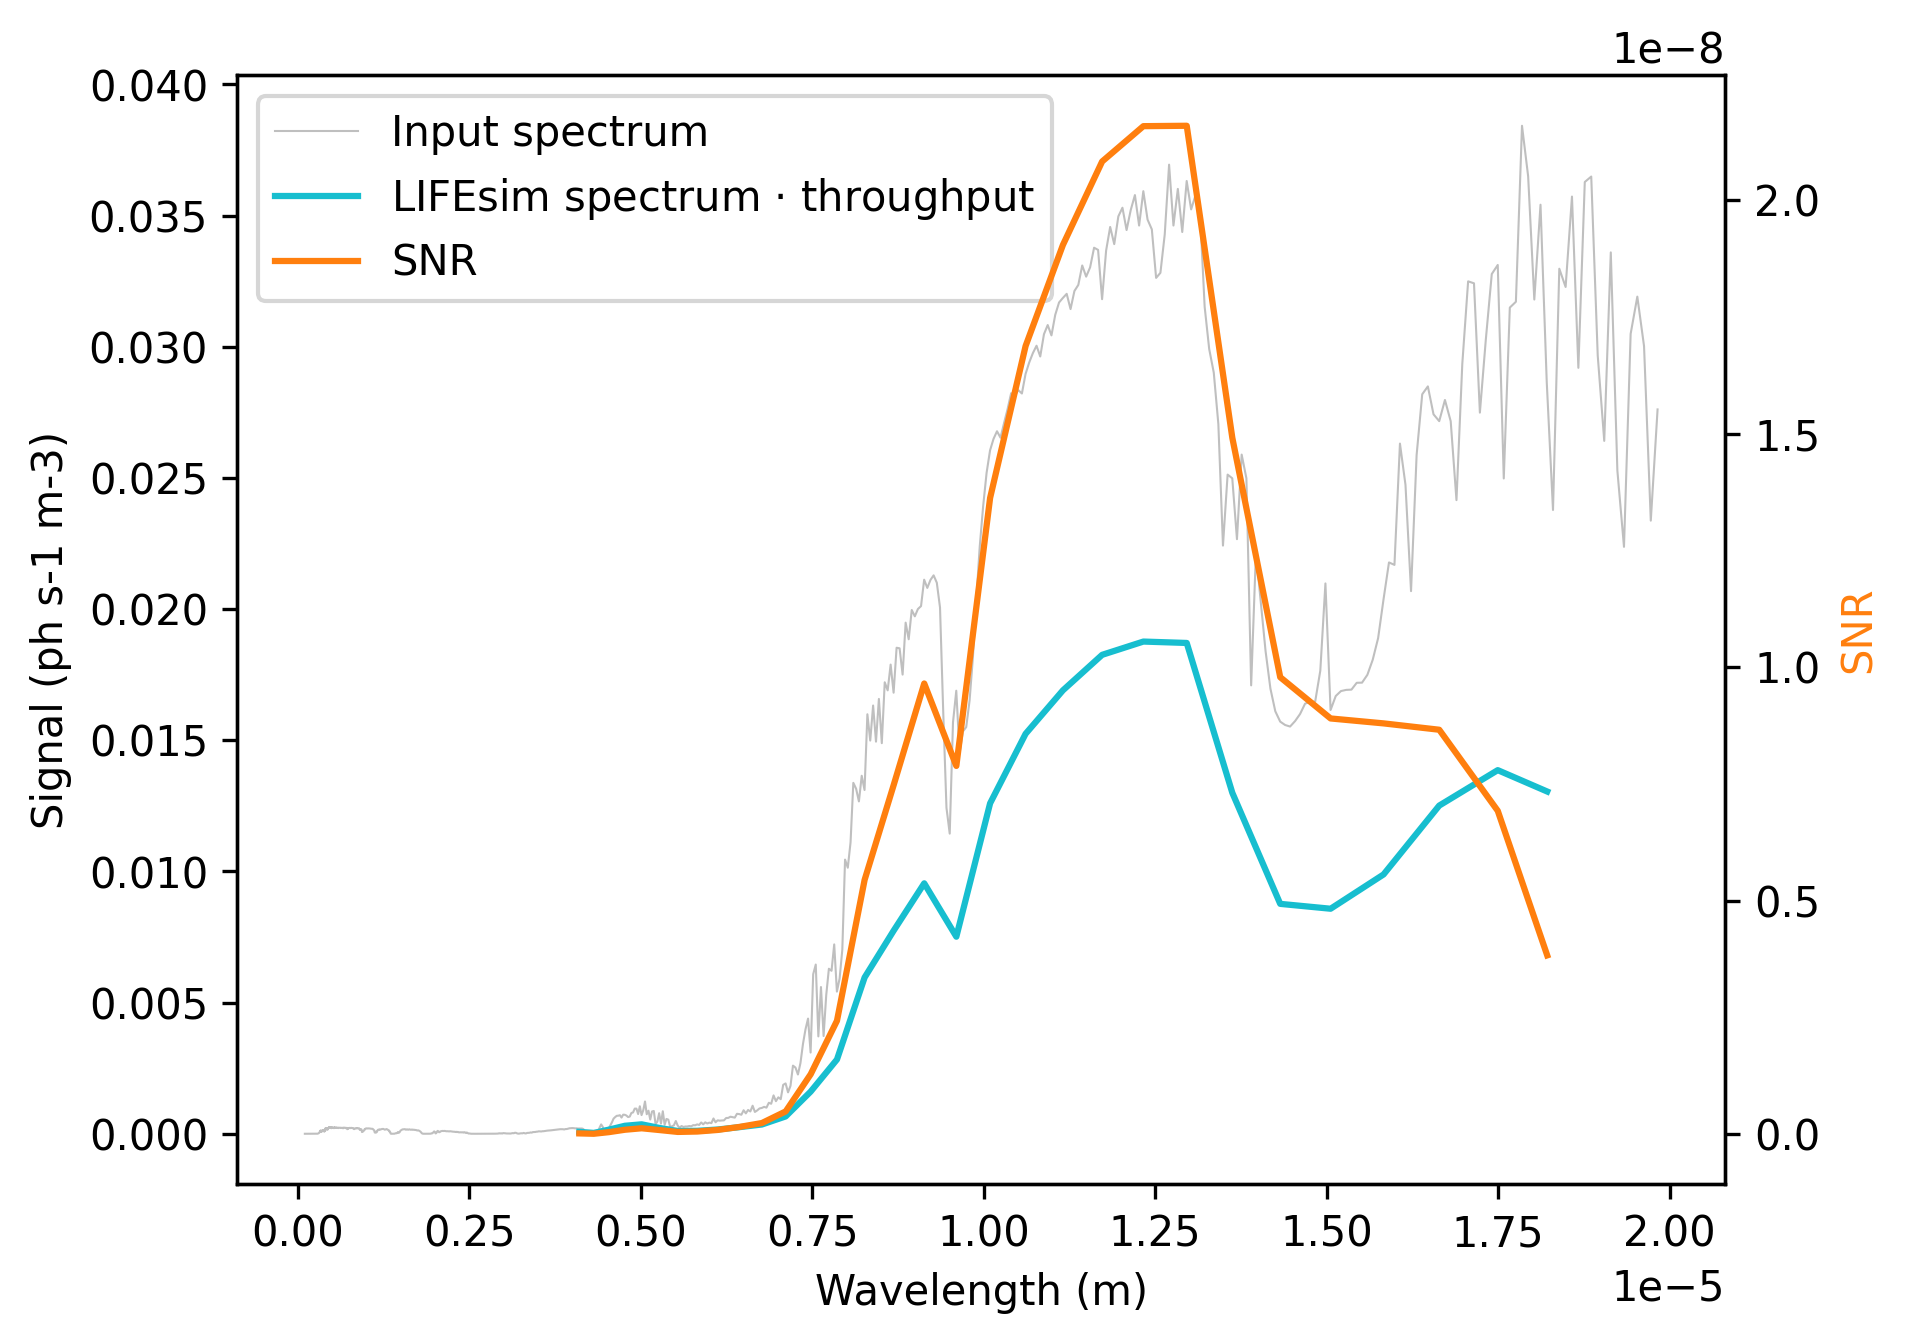

In [32]:
fig, ax = plt.subplots(dpi=300)
ln1 = plt.plot(lam_lifesim, f_lifesim, lw=0.5, c='gray', alpha=0.5, label='Input spectrum')
ln2 = plt.plot(spectrum_tmo[0], flux_planet_tmo / prefactor, c='tab:cyan', label='LIFEsim spectrum $\cdot$ throughput')
ax2=ax.twinx()
ln3 = ax2.plot(spectrum_tmo[0], spectrum_tmo[1],c='tab:orange', label='SNR')

lns = ln1 + ln2 + ln3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)

ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph s-1 m-3)')
ax2.set_ylabel("SNR",c='tab:orange')
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_32869/1925093298.py:3: SyntaxWarning: invalid escape sequence '\c'
  ln2 = plt.plot(spectrum_noinst[0], flux_planet_noinst / prefactor_noinst, c='tab:cyan', label='LIFEsim spectrum $\cdot$ throughput')


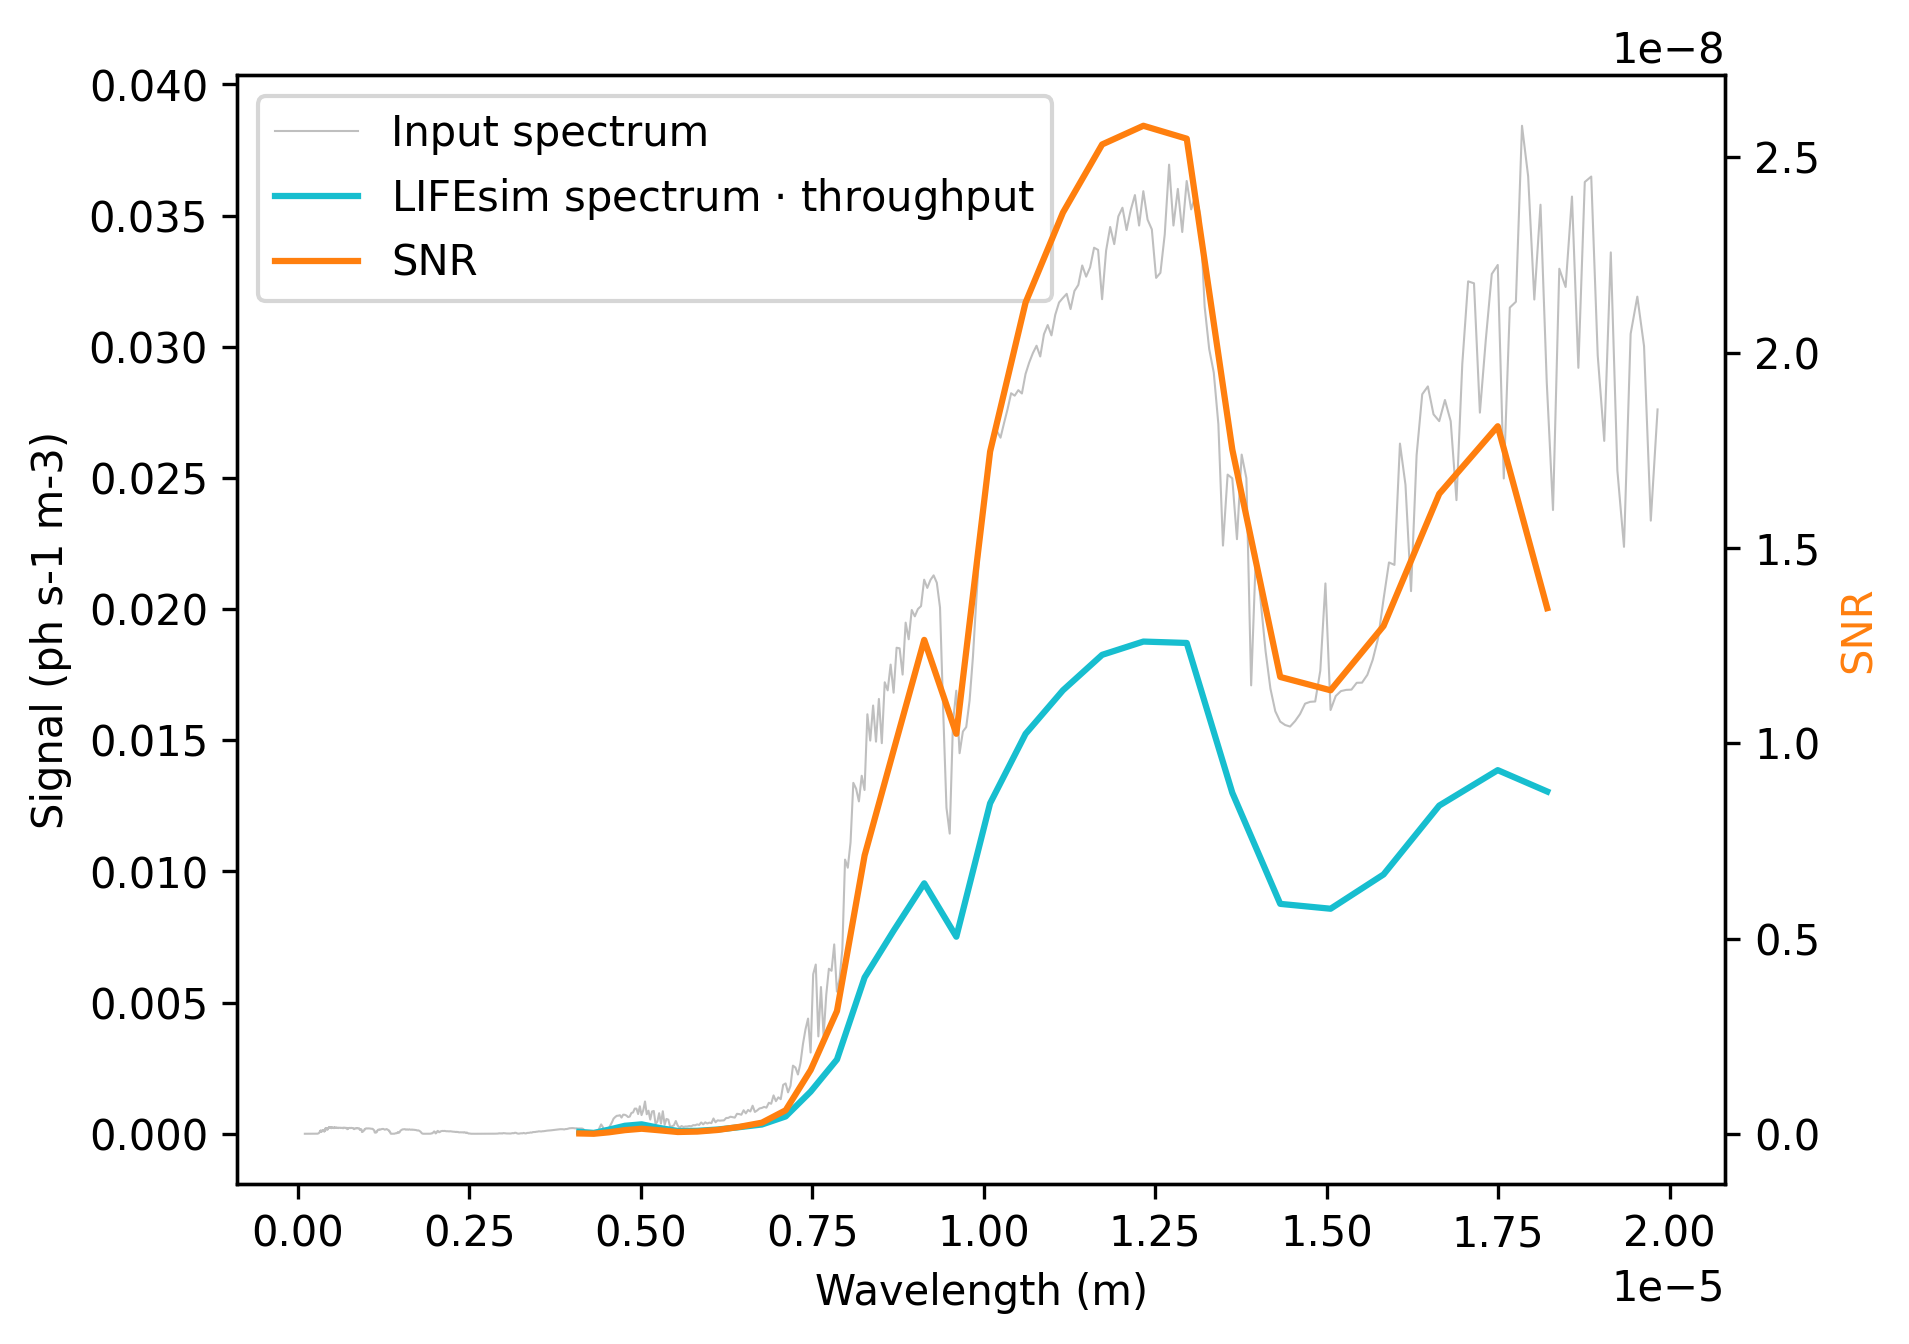

In [33]:
fig, ax = plt.subplots(dpi=300)
ln1 = plt.plot(lam_lifesim, f_lifesim, lw=0.5, c='gray', alpha=0.5, label='Input spectrum')
ln2 = plt.plot(spectrum_noinst[0], flux_planet_noinst / prefactor_noinst, c='tab:cyan', label='LIFEsim spectrum $\cdot$ throughput')
ax2=ax.twinx()
ln3 = ax2.plot(spectrum_noinst[0], spectrum_noinst[1],c='tab:orange', label='SNR')

lns = ln1 + ln2 + ln3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)

ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph s-1 m-3)')
ax2.set_ylabel("SNR",c='tab:orange')
plt.show()

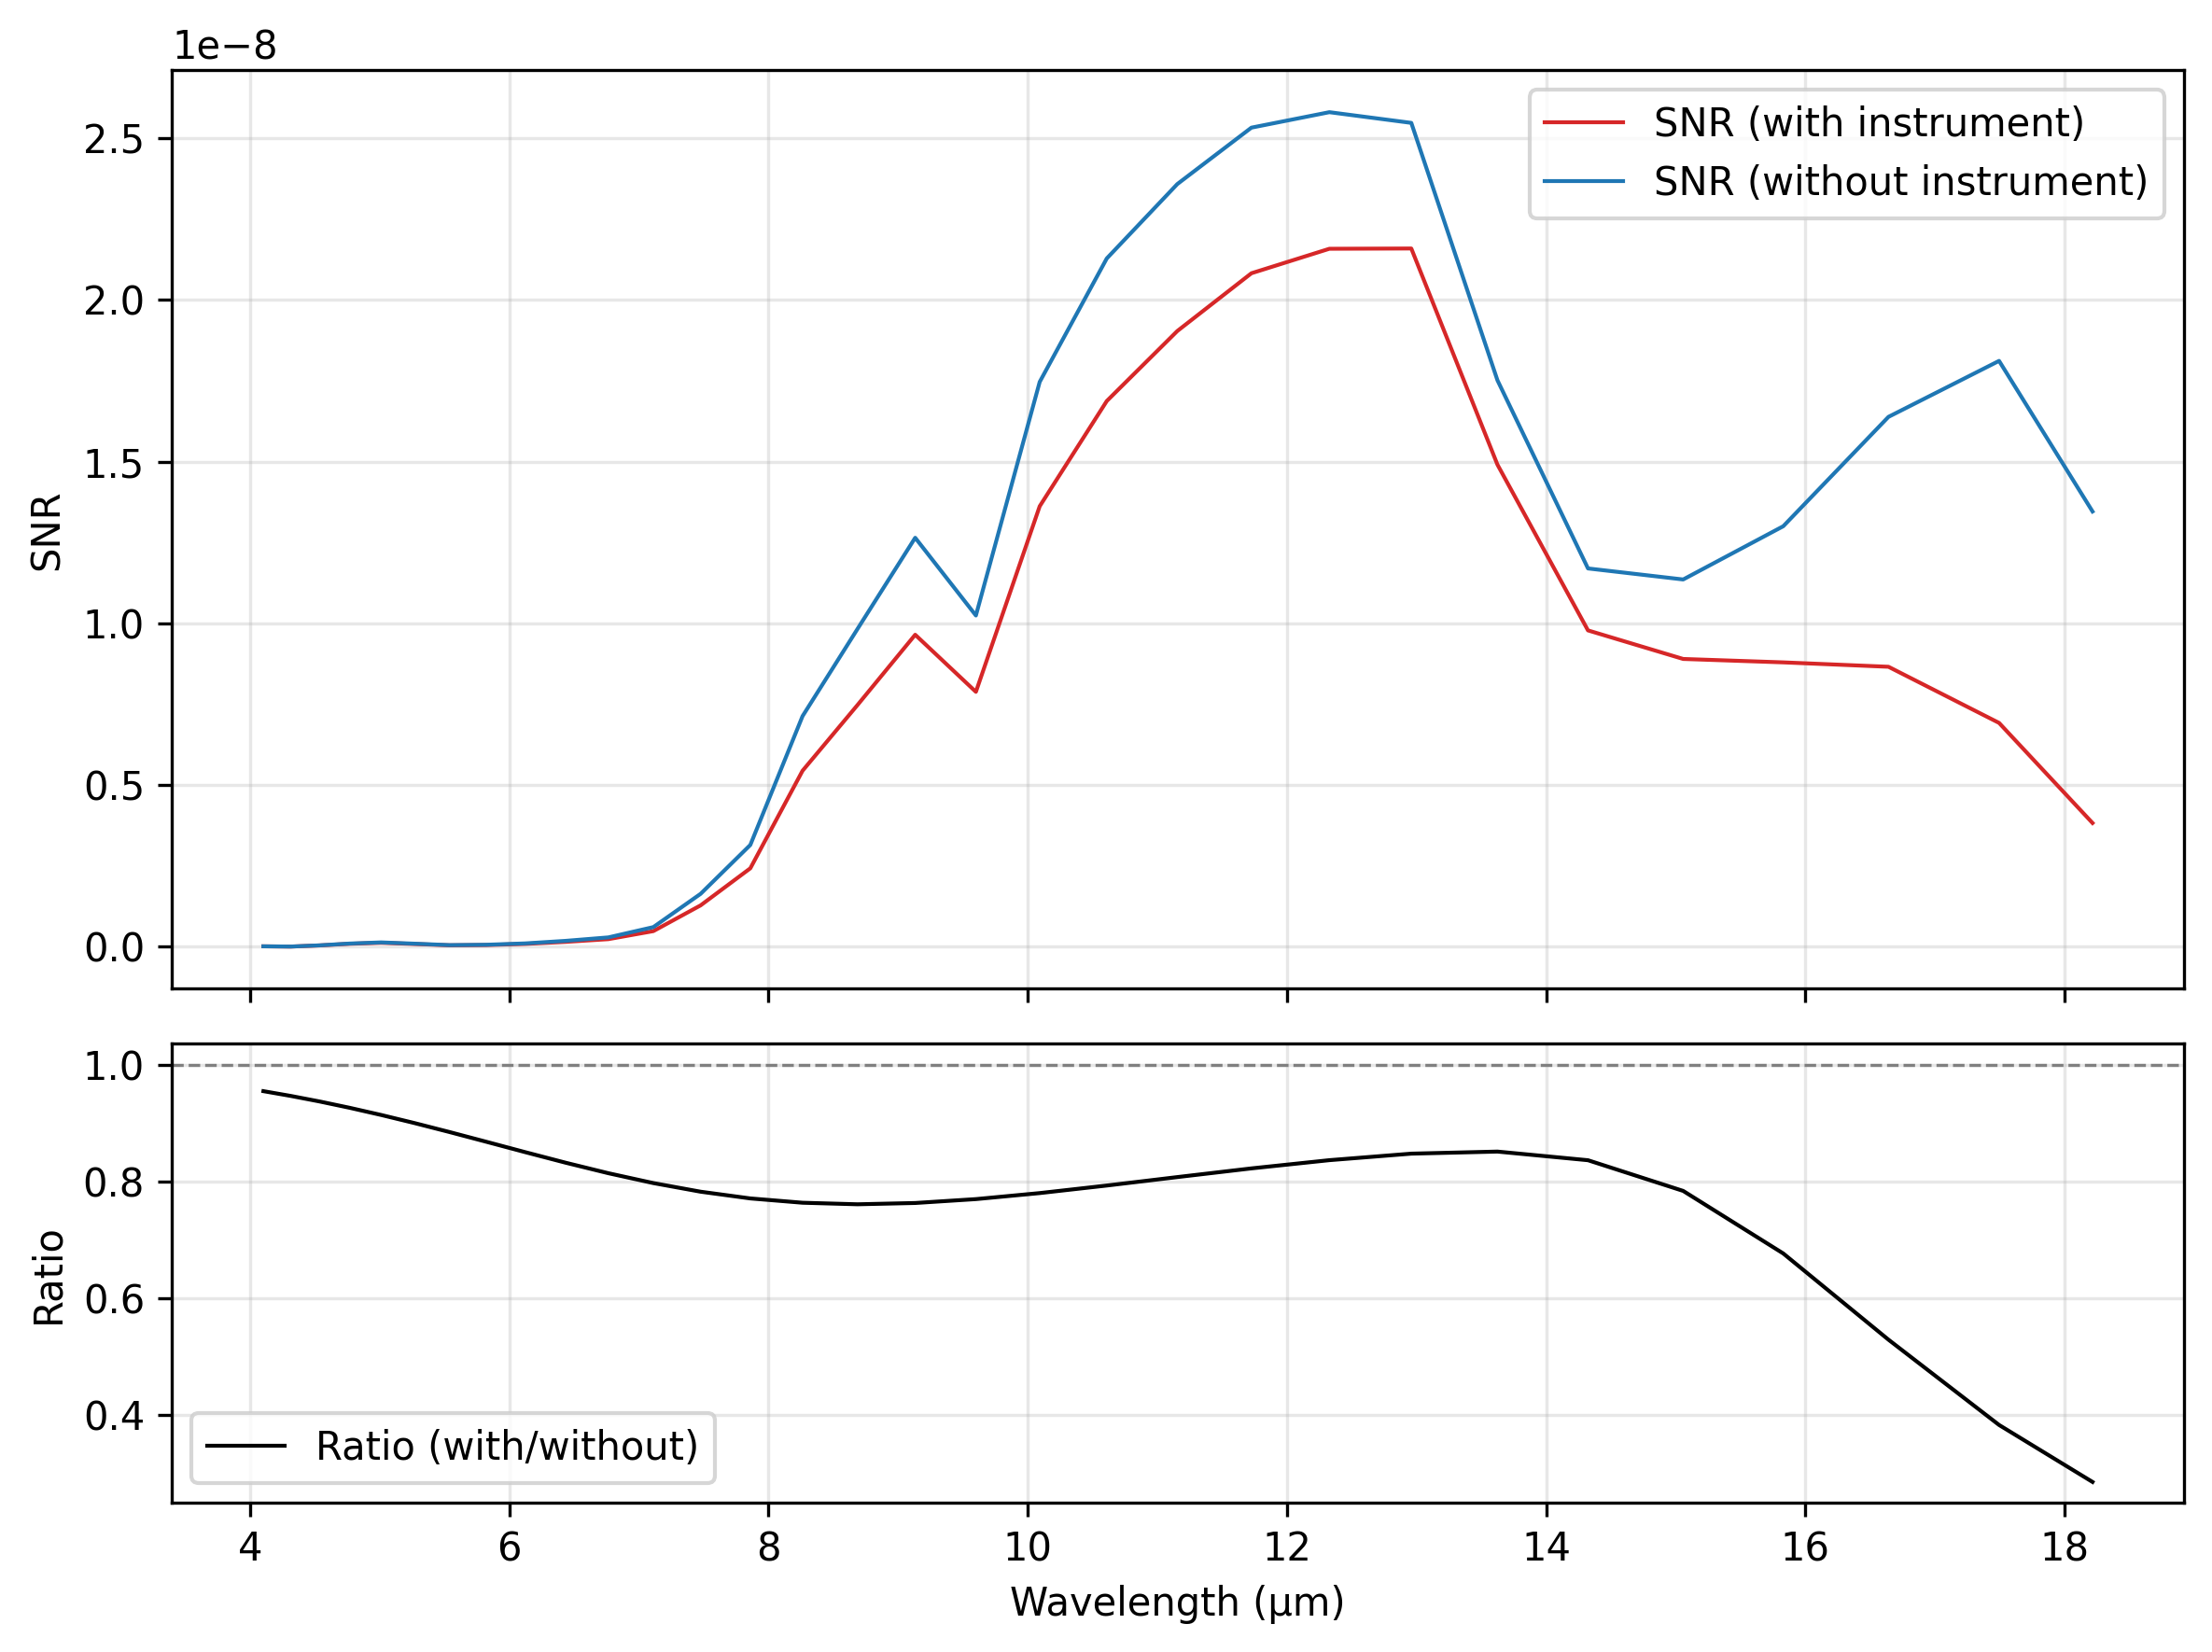

In [34]:
snr_with_inst = spectrum_tmo[1]
snr_without_inst = spectrum_noinst[1]
snr_ratio = np.divide(
    snr_with_inst,
    snr_without_inst,
    out=np.full_like(snr_with_inst, np.nan),
    where=snr_without_inst != 0
)

wavelength_um = spectrum_tmo[0] * 1e6

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(8, 6), dpi=300, sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

ax1.plot(wavelength_um, snr_with_inst, label="SNR (with instrument)", color="tab:red", lw=1)
ax1.plot(wavelength_um, snr_without_inst, label="SNR (without instrument)", color="tab:blue", lw=1)
ax1.set_ylabel("SNR")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(wavelength_um, snr_ratio, label="Ratio (with/without)", color="black", lw=1)
ax2.axhline(1.0, color="gray", ls="--", lw=0.8)
ax2.set_xlabel("Wavelength (µm)")
ax2.set_ylabel("Ratio")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
noise_star = noise_tmo[1]
noise_star_local = noise_star[0]
noise_star_starleak = noise_star[1]

noise_universe = noise_tmo[2][0]

noise_thermal = noise_tmo[3] 
noise_thermal_mirror = noise_thermal[0]
noise_thermal_detector = noise_thermal[1]
noise_thermal_inst = noise_thermal[2]

noise_dc_electron = noise_tmo[4][0]
noise_dc_photon = noise_dc_electron/0.7

noise_planet = noise_tmo[0]/integration_time/bus.data.inst['eff_tot']/bus.data.options.array['num_outputs'] - noise_star_local - noise_star_starleak - noise_universe - noise_thermal_mirror - noise_thermal_detector - noise_dc_photon

In [36]:
noise_star_noinst = noise_noinst[1]
noise_star_local_noinst = noise_star_noinst[0]
noise_star_starleak_noinst = noise_star_noinst[1]

noise_universe_noinst = noise_noinst[2][0]

noise_thermal_noinst = noise_noinst[3] 
noise_thermal_mirror_noinst = noise_thermal_noinst[0]
noise_thermal_detector_noinst = noise_thermal_noinst[1]
noise_thermal_inst_noinst = noise_thermal_noinst[2]

# SNR calculations catalog

In [53]:
bus.data.catalog_from_ppop(input_path='/home/kirschkobold/documents/life_internship/LIFEsim_yields/ppop_catalog/ppop_catalog.txt', overwrite=True)
bus.data.catalog_from_ppop(input_path='/home/kirschkobold/documents/life_internship/LIFEsim_yields/eta_catalogs/scaled_etaEEC_AFGK/NewRefScen_AFGK_Bryson2021Model1Hab2High_etaEEC25.txt', overwrite=True)
bus.data.catalog_remove_distance(stype='A', mode='larger', dist=0.)  # remove all A stars
bus.data.catalog_remove_distance(stype='M', mode='larger', dist=10.)  # remove M stars > 10pc to
# speed up calculation

Processed line 10000 of 33048

Processed line 33048 of 33048
Processed line 915939 of 915939


In [54]:
bus_noinst.data.catalog_from_ppop(input_path='/home/kirschkobold/documents/life_internship/LIFEsim_yields/ppop_catalog/ppop_catalog.txt', overwrite=True)
bus_noinst.data.catalog_from_ppop(input_path='/home/kirschkobold/documents/life_internship/LIFEsim_yields/eta_catalogs/scaled_etaEEC_AFGK/NewRefScen_AFGK_Bryson2021Model1Hab2High_etaEEC25.txt', overwrite=True)
bus_noinst.data.catalog_remove_distance(stype='A', mode='larger', dist=0.)  # remove all A stars
bus_noinst.data.catalog_remove_distance(stype='M', mode='larger', dist=10.)  # remove M stars > 10pc to
# speed up calculation

Processed line 10000 of 33048

Processed line 33048 of 33048
Processed line 915939 of 915939


In [68]:
# optimizing the result
opt = lifesim.Optimizer(name='opt')
bus.add_module(opt)
ahgs = lifesim.AhgsModule(name='ahgs')
bus.add_module(ahgs)

bus.connect(('transm', 'opt'))
bus.connect(('inst', 'opt'))
bus.connect(('opt', 'ahgs'))

ValueError: The module name opt is already in use in this bus

In [76]:
instrument.get_snr()

  0%|          | 0/1664 [00:00<?, ?it/s]

  7%|▋         | 124/1664 [10:25<2:09:30,  5.05s/it]


KeyboardInterrupt: 

In [ ]:
# optimizing the result
opt_noinst = lifesim.Optimizer(name='opt_noinst')
bus_noinst.add_module(opt_noinst)
ahgs_noinst = lifesim.AhgsModule(name='ahgs_noinst')
bus_noinst.add_module(ahgs_noinst)

bus_noinst.connect(('transm_noinst', 'opt_noinst'))
bus_noinst.connect(('inst_noinst', 'opt_noinst'))
bus_noinst.connect(('opt_noinst', 'ahgs_noinst'))

In [57]:
instrument_noinst.get_snr()

100%|██████████| 1664/1664 [1:09:21<00:00,  2.50s/it]


In [71]:
bus.data.optm

{'sum_detected': array([0., 0., 0., 0., 0.]),
 'num_universe': 10,
 'hit_limit': {'F': False, 'G': False, 'K': False, 'M': False},
 'exp_detected': {'F': 10, 'G': 24, 'K': 79, 'M': 127},
 'exp_detected_uni': {'F': array([[0., 1., 2., 3., 4., 5., 6., 7., 8., 9.],
         [2., 2., 1., 0., 0., 1., 1., 2., 0., 1.]]),
  'G': array([[0., 1., 2., 3., 4., 5., 6., 7., 8., 9.],
         [2., 3., 1., 1., 1., 2., 3., 5., 4., 2.]]),
  'K': array([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.],
         [ 6.,  4.,  9., 11.,  7.,  5., 11., 10., 11.,  5.]]),
  'M': array([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.],
         [ 8., 10., 16., 18., 10., 11., 16., 14., 13., 11.]])},
 'tot_time': np.float64(63072000.0)}

In [72]:
opt.ahgs()

AttributeError: 'NoneType' object has no attribute 'optm'

In [60]:
opt_noinst.ahgs()

Number of planets detected for each experiment:
F: 12.242  G: 12.612  K: 14.534  M: 0.0  -  (2.0 / 2.0) yrs observed


In [73]:
# print(bus.data.catalog['detected'].value_counts())
print(bus_noinst.data.catalog['detected'].value_counts())

detected
False    781973
True      19327
Name: count, dtype: int64


In [74]:
# print(bus.data.catalog['snr_1h'].mean())
print(bus_noinst.data.catalog['snr_1h'].mean())
# print(bus.data.catalog['snr_1h'].median())
print(bus_noinst.data.catalog['snr_1h'].median())
# print(f"factor: {bus.data.catalog['snr_1h'].mean()/bus_noinst.data.catalog['snr_1h'].mean()}")
# print(f"factor: {bus.data.catalog['snr_1h'].median()/bus_noinst.data.catalog['snr_1h'].median()}")


0.2239405129992166
0.06183224262076978


In [ ]:
(bus.data.catalog['snr_1h']/bus_noinst.data.catalog['snr_1h']).mean()

np.float64(0.7026950887253429)

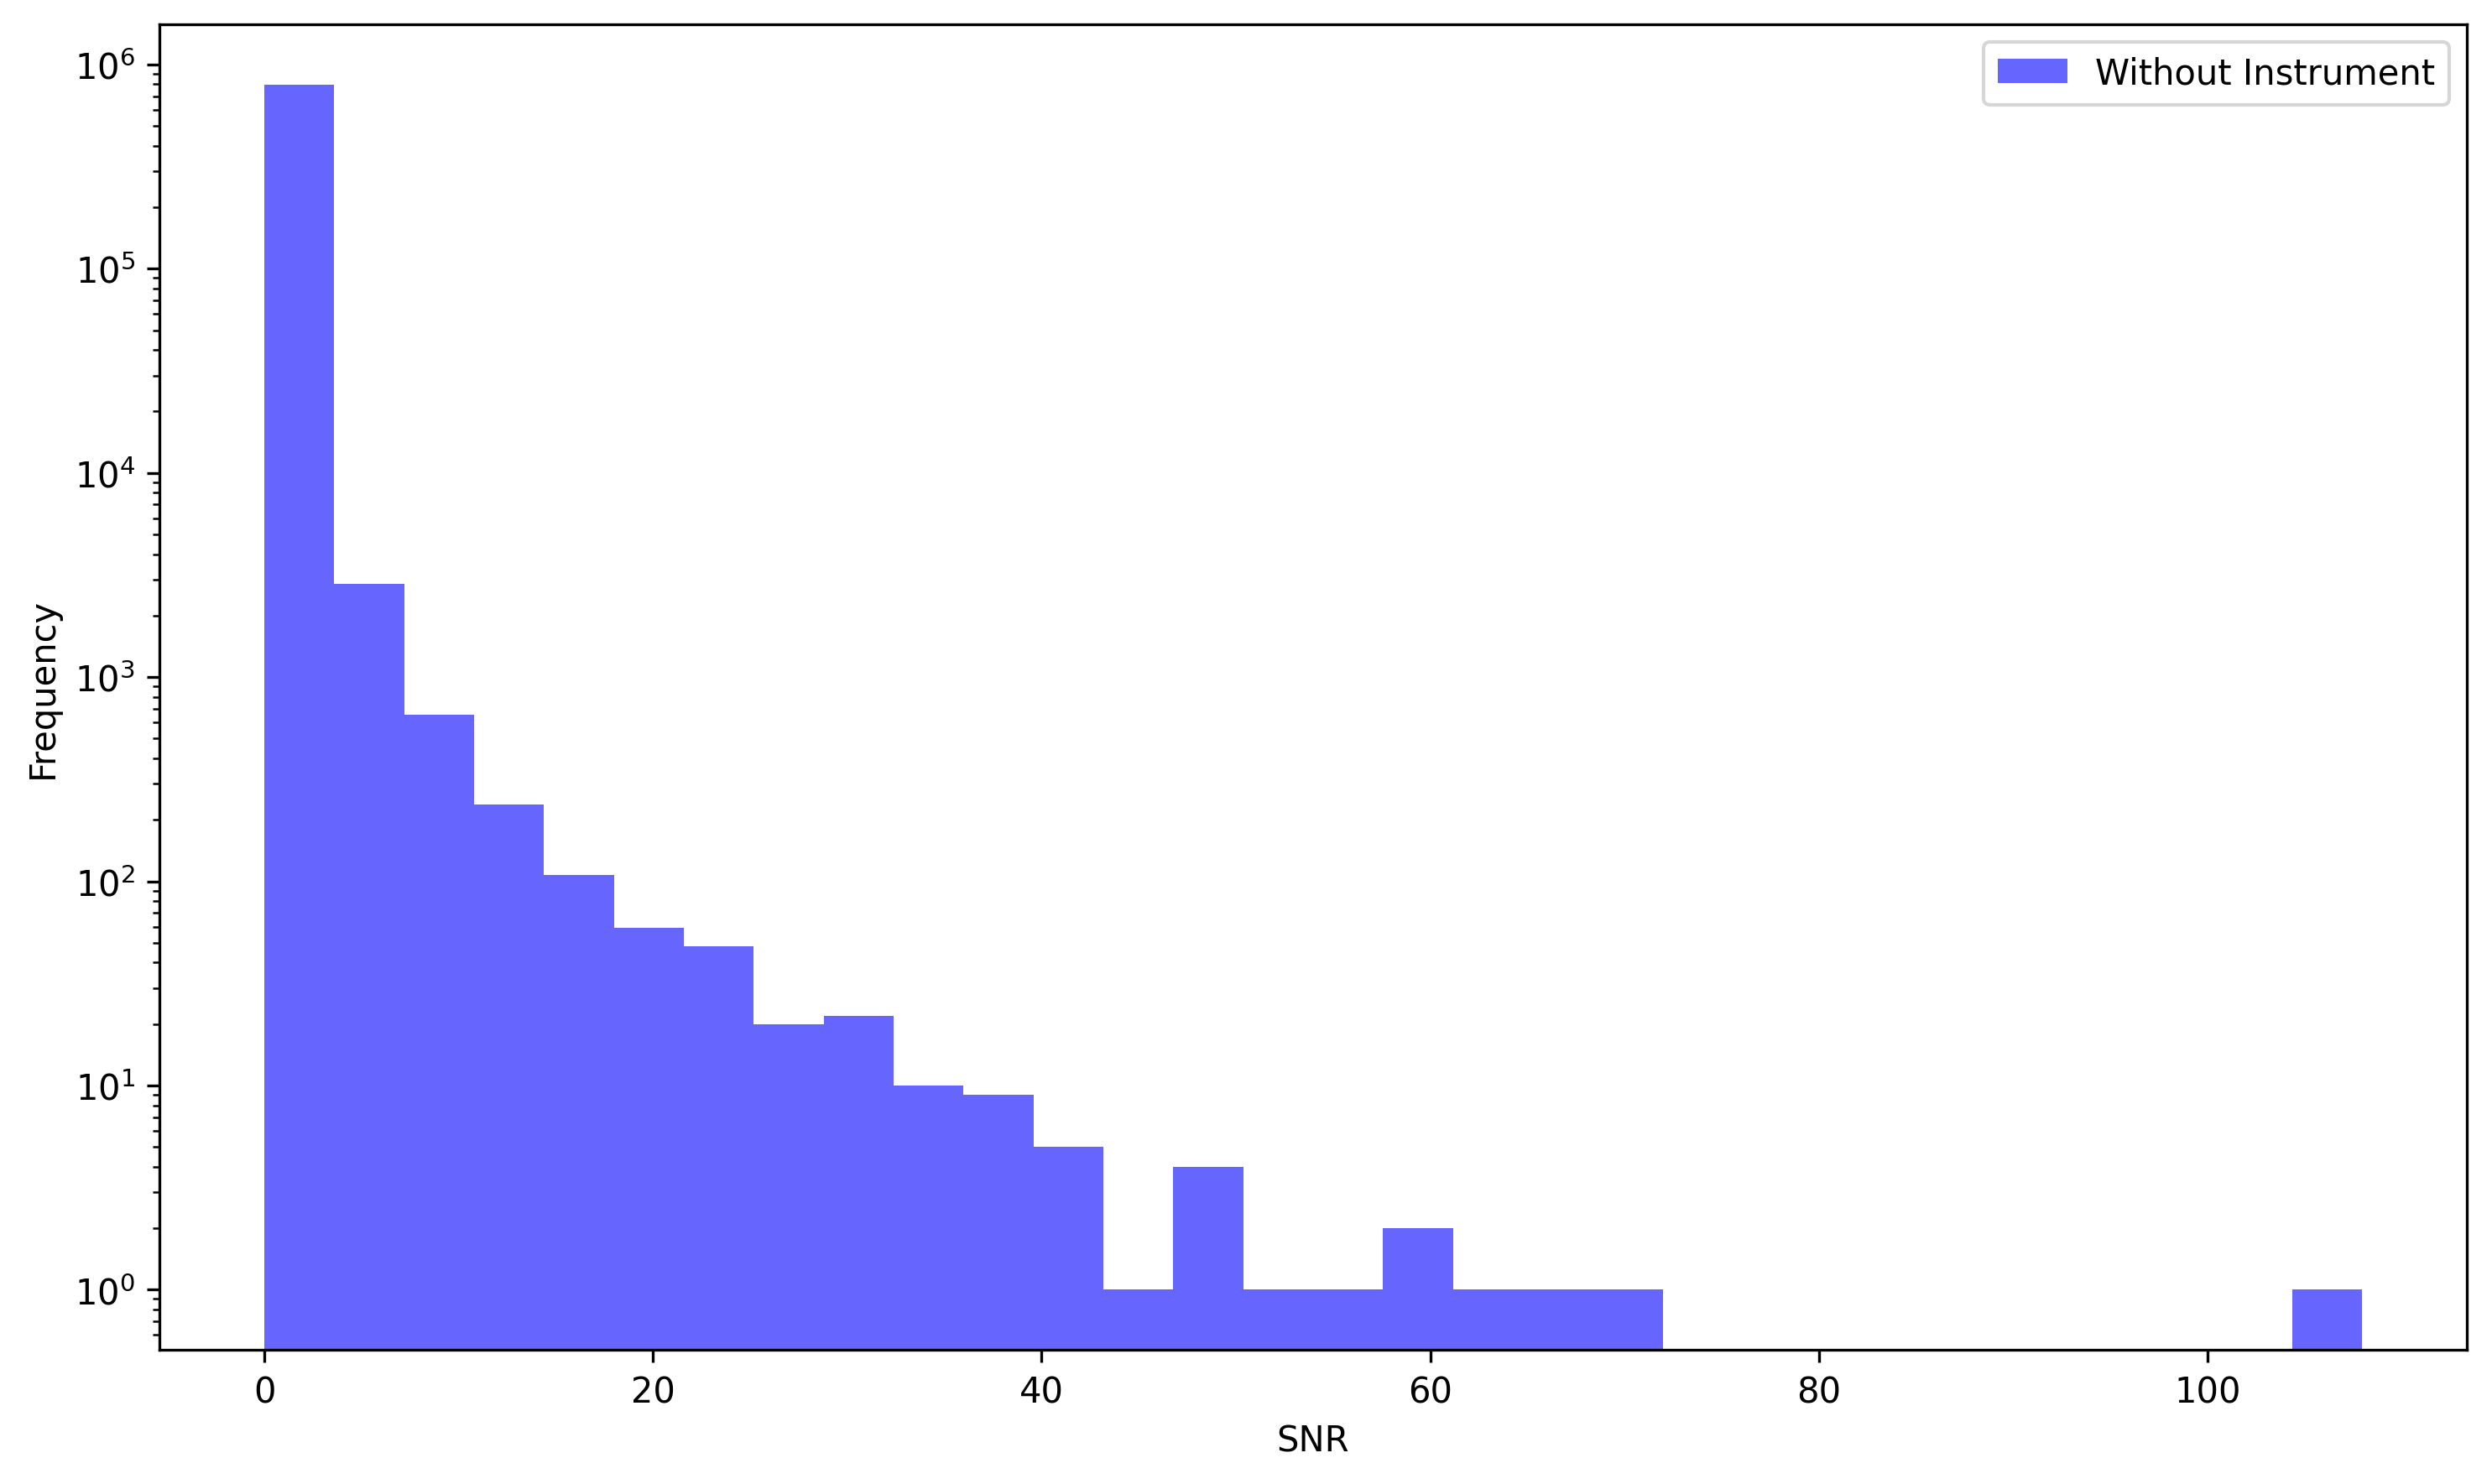

In [75]:
fig, ax = plt.subplots(dpi=300, figsize=(10, 6))

# ax.hist(bus.data.catalog['snr_1h'], bins=30, color='red', alpha=0.6, label='With Instrument')
ax.hist(bus_noinst.data.catalog['snr_1h'], bins=30, color='blue', alpha=0.6, label='Without Instrument')

ax.set_xlabel('SNR')
ax.set_ylabel('Frequency')
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.show()

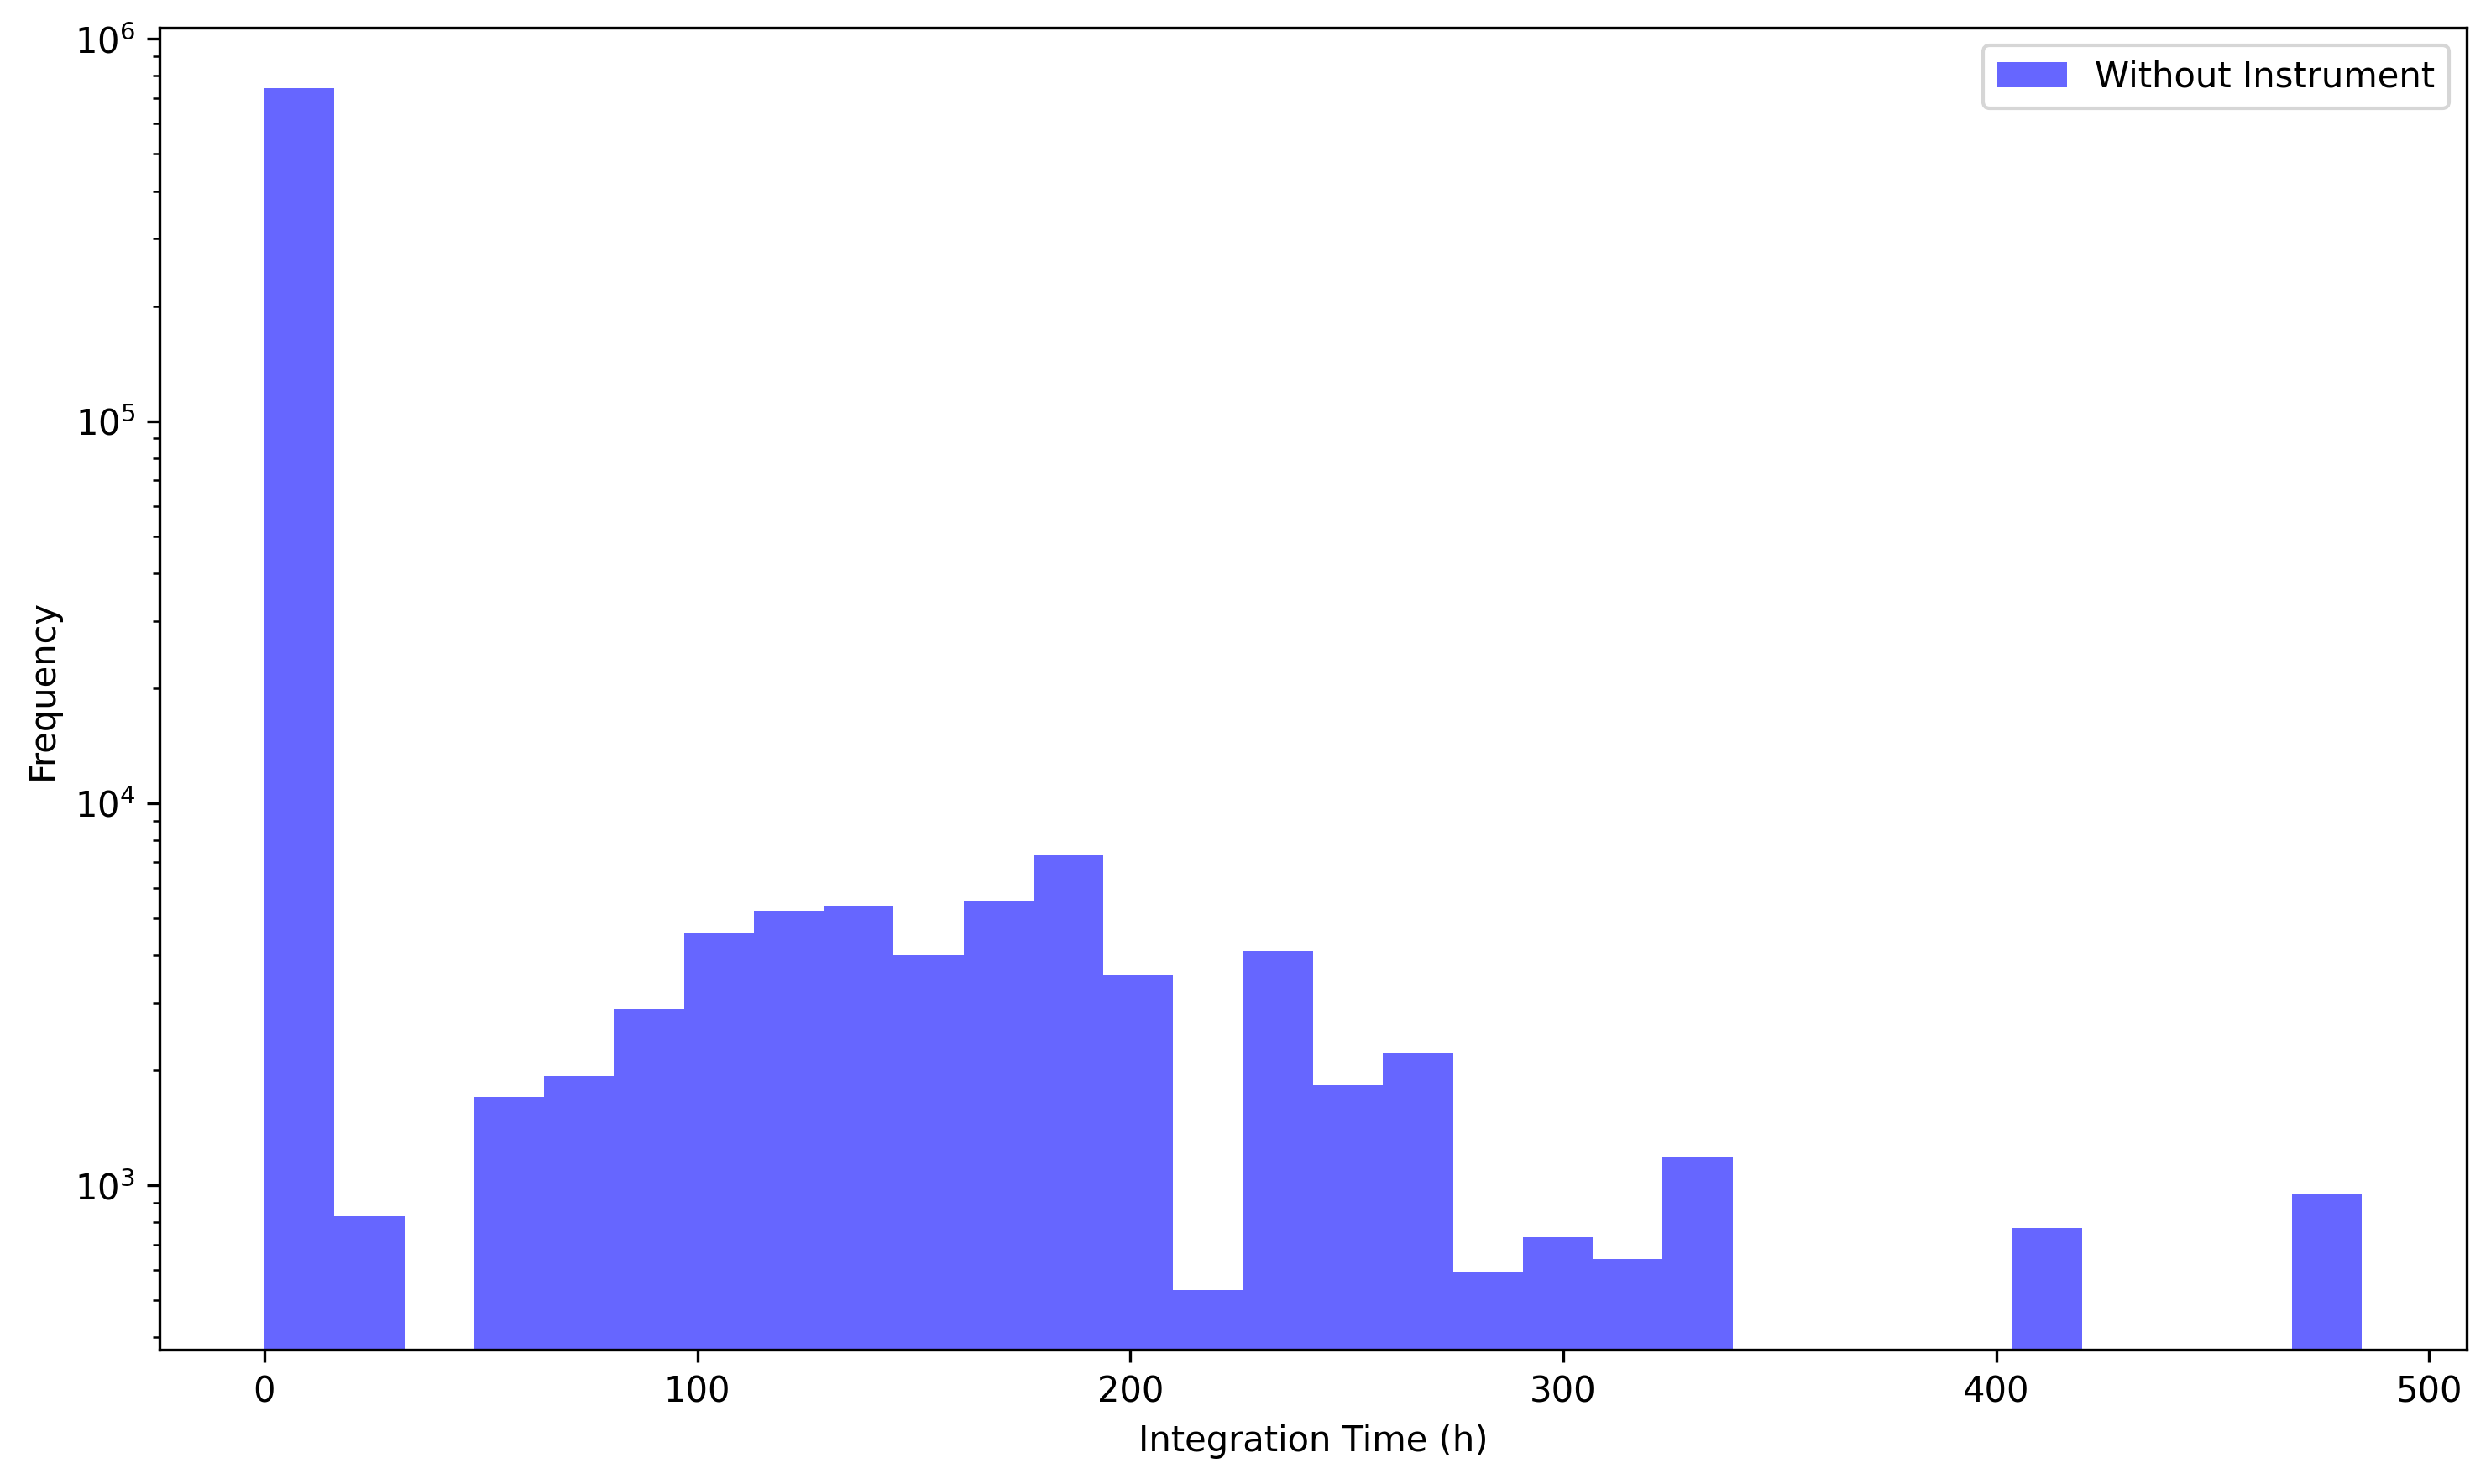

In [77]:
fig, ax = plt.subplots(dpi=300, figsize=(10, 6))

# ax.hist(bus.data.catalog['int_time']/60/60, bins=30, color='red', alpha=0.6, label='With Instrument')
ax.hist(bus_noinst.data.catalog['int_time']/60/60, bins=30, color='blue', alpha=0.6, label='Without Instrument')

ax.set_xlabel('Integration Time (h)')
ax.set_ylabel('Frequency')
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.show()

In [ ]:
print(bus.data.catalog['t_detected'].max())
print(bus_noinst.data.catalog['t_detected'].max())

63072000.0
63072000.0


In [ ]:
print(len(bus.data.catalog['t_detected'] < 31536000))
print(len(bus_noinst.data.catalog['t_detected'] < 31536000))

7777
7777
